# The Maltese Domestic Waste Dataset (MDWD) — Exploratory Data Analysis

**MSc Dissertation — University of Malta**

This notebook presents a systematic exploratory analysis of the Maltese Domestic Waste
Dataset (MDWD), a street-level image corpus of kerbside domestic waste captured across
Malta and annotated for object detection with five classes (`Mixed Waste`, `Orange CMD`,
`Organic Waste`, `Other Waste`, `Recyclable Material`). The analysis characterises:

1. the **corpus composition** (splits, augmented-export structure, unique sources);
2. the **class balance** overall and per split;
3. the **bounding-box geometry** (area, aspect ratio, COCO size classes, spatial layout); and
4. the **dataset integrity** (label/image pairing, coordinate validity, split leakage).

Every figure is exported at 300 dpi to `Documents/MDWD-EDA/Figures/` and every summary
table to `Documents/MDWD-EDA/GeneratedCSVs/`, so all artefacts can be referenced directly
from the dissertation text.

### Methodological notes

- **The working data is a Roboflow export** (project v20, 640×640 stretch resize, ~10×
  augmentation applied to the training split only). The export exists in four
  framework-specific variants of the *same* data — `MDWD-YOLO11/12/26` (YOLO layout) and
  `MDWD-RFDETR` (COCO layout). The analysis defaults to `MDWD-YOLO26`; the mapper
  auto-detects the annotation format, so any variant can be selected in §1.
- **Augmentation-aware statistics.** Because train images are augmented copies, counts are
  reported both at export level (30k+ images) and at *unique-source* level (`source_stem`,
  the Roboflow name before `.rf.<hash>`); mixing the two would misstate the corpus size.
- **Reusable logic lives in the `mdwd_eda` package** (`config` / `mapper` / `checks` /
  `stats` / `plotstyle`) and `run_eda.py`. This notebook imports and *presents* that logic;
  it does not reimplement it, so the CLI (`python run_eda.py`) and this notebook always
  agree. Re-running the notebook top-to-bottom regenerates every figure and table.

### Contents

1. [Setup and configuration](#1-Setup-and-configuration)
2. [Dataset mapping and integrity](#2-Dataset-mapping-and-integrity)
3. [Artefact generation](#3-Artefact-generation)
4. [Corpus composition](#4-Corpus-composition)
5. [Class balance](#5-Class-balance)
6. [Instance density](#6-Instance-density)
7. [Bounding-box geometry](#7-Bounding-box-geometry)
8. [Resolutions and spatial layout](#8-Resolutions-and-spatial-layout)
9. [Class co-occurrence](#9-Class-co-occurrence)
10. [Annotated samples](#10-Annotated-samples)
11. [Summary and exported artefacts](#11-Summary-and-exported-artefacts)


## 1. Setup and configuration

The analysis depends only on the scientific Python stack plus the local `mdwd_eda`
support package (dataset mapping, integrity checks, statistics, and the figure style).
Library versions are printed for the record.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

if not any((Path(p) / "mdwd_eda").is_dir() for p in sys.path if p):
    sys.path.insert(0, str(Path.cwd()))

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from mdwd_eda import checks, config, plotstyle, stats
from mdwd_eda.mapper import build_map

plotstyle.apply()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(f"{'Python':<12} {sys.version.split()[0]}")
for module in (np, pd, mpl):
    print(f"{module.__name__:<12} {module.__version__}")
print(f"{'Repository':<12} {config.BASE_DIR}")


Python       3.12.11
numpy        2.0.1
pandas       2.3.3
matplotlib   3.10.6
Repository   E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark


In [2]:
# Analysis switches -----------------------------------------------------------
# VARIANT selects which export under Datasets/MDWD is analysed; the annotation
# format (YOLO vs COCO) is detected automatically. MAX_IMAGES caps each split
# for a quick sample run (None = full corpus; cross-split checks need None).
VARIANT = config.DEFAULT_VARIANT          # "MDWD-YOLO26"
MAX_IMAGES = None

config.ensure_output_dirs()
available = ", ".join(p.name for p in config.discover_variants())
print(f"Available variants : {available}")
print(f"Selected variant   : {VARIANT}")
print(f"Figure output      : {config.FIGURES_DIR}")
print(f"CSV output         : {config.CSV_DIR}")


Available variants : MDWD-YOLO26, MDWD-RFDETR, MDWD-YOLO11, MDWD-YOLO12
Selected variant   : MDWD-YOLO26
Figure output      : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA\Figures
CSV output         : E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA\GeneratedCSVs


## 2. Dataset mapping and integrity

`mdwd_eda.mapper.build_map` indexes every image (dimensions read from headers, no full
decode) and every bounding box, and records integrity findings as it goes. The checks
cover: missing/unreadable images, missing label files, orphan labels, malformed label
rows, invalid class ids, out-of-range coordinates, empty annotations, duplicate
filenames, and augmented copies of one source image leaking across splits.


In [3]:
dataset_map = build_map(VARIANT, max_images=MAX_IMAGES)

print(f"Variant  : {dataset_map.variant}  ({dataset_map.format.upper()} format)")
print(f"Classes  : {dataset_map.class_names}")
print(f"Images   : {len(dataset_map.images):,}")
print(f"Boxes    : {len(dataset_map.boxes):,}")

split_overview = stats.split_overview(dataset_map)
display(split_overview)


Variant  : MDWD-YOLO26  (YOLO format)
Classes  : ['Mixed Waste', 'Orange CMD', 'Organic Waste', 'Other Waste', 'Recyclable Material']
Images   : 30,225
Boxes    : 211,512


,split,images,unique_source_images,boxes,boxes_per_image_mean,boxes_per_image_median,boxes_per_image_max,images_without_boxes
0,train,29487,2891,209334,7.099,6.0,42,5
1,valid,369,369,1072,2.905,2.0,18,0
2,test,369,368,1106,2.997,2.0,28,0
3,TOTAL,30225,3598,211512,6.998,6.0,42,5


In [4]:
integrity = checks.integrity_summary(dataset_map)
display(integrity[integrity["count"] > 0] if (integrity["count"] > 0).any() else integrity)

issues = checks.issues_table(dataset_map)
if len(issues):
    print(f"{len(issues)} individual findings (full list exported in §3); first few:")
    display(issues.head(10))
else:
    print("No integrity issues found.")


,issue,count,description
6,empty_annotation,5,image has an annotation entry but zero boxes
9,out_of_range_box,15,box coordinates fall outside the image bounds
11,source_in_multiple_splits,30,augmented copies of one source image appear in...


50 individual findings (full list exported in §3); first few:


,type,split,file,detail
0,out_of_range_box,train,473448940_615763551007064_269417391686000009_n...,line 9
1,out_of_range_box,train,ARI3129_SDM_73_jpg.rf.0fbb70d78fff697cd7a28798...,line 5
2,empty_annotation,train,ARI3129_TK_76_jpg.rf.be9b8f5cf041aa7042a5a9dc8...,NaN
3,out_of_range_box,train,ARI3129_TK_80_jpg.rf.8c5047a7cd420055e57597f7f...,line 2
4,empty_annotation,train,CMD-Batch1_108_jpeg.rf.729768dc0b9b62a7e60c6ec...,NaN
5,out_of_range_box,train,CMD-Batch1_151_jpeg.rf.5533559aa3de8ae698be773...,line 3
6,empty_annotation,train,image00094_jpeg.rf.5dc9d7dab7a5842d30c04d175ee...,NaN
7,out_of_range_box,train,IMG_0210_JPG.rf.83286e23a8cd8dd360dbe235dcfa1b...,line 1
8,out_of_range_box,train,IMG_0689_jpeg.rf.70f86cd8ca2e437ccf19efbe49607...,line 1
9,out_of_range_box,train,IMG_0712_jpeg.rf.d8d792231d3bd80e08fe91ee48383...,line 4


## 3. Artefact generation

One call regenerates the full artefact set used by the dissertation — 11 CSV tables,
10 figures (300 dpi PNG) and `eda_summary.json` — via the same functions the
`run_eda.py` CLI uses. The remaining sections present each artefact with commentary.


In [5]:
import run_eda  # noqa: E402  (sibling module: chart functions + table writer)

written_tables = run_eda.write_tables(dataset_map, config.CSV_DIR)
for chart in run_eda.CHARTS:
    chart(dataset_map, config.FIGURES_DIR)

import json as _json
from datetime import datetime, timezone

summary = stats.to_native(stats.summary_dict(dataset_map))
summary["generated_at"] = datetime.now(timezone.utc).isoformat(timespec="seconds")
summary["max_images"] = MAX_IMAGES
config.SUMMARY_JSON.write_text(_json.dumps(summary, indent=2) + "\n", encoding="utf-8")

print(f"{len(written_tables)} tables -> {config.CSV_DIR}")
print(f"{len(run_eda.CHARTS)} figures -> {config.FIGURES_DIR}")
print(f"Summary -> {config.SUMMARY_JSON}")


11 tables -> E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA\GeneratedCSVs
10 figures -> E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA\Figures
Summary -> E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA\eda_summary.json


## 4. Corpus composition

The export is heavily skewed towards the training split by construction: Roboflow's
~10× offline augmentation is applied to train only, while validation and test remain
un-augmented originals. The unique-source counts in the §2 table are therefore the
honest measure of corpus size; the export counts describe the training distribution.


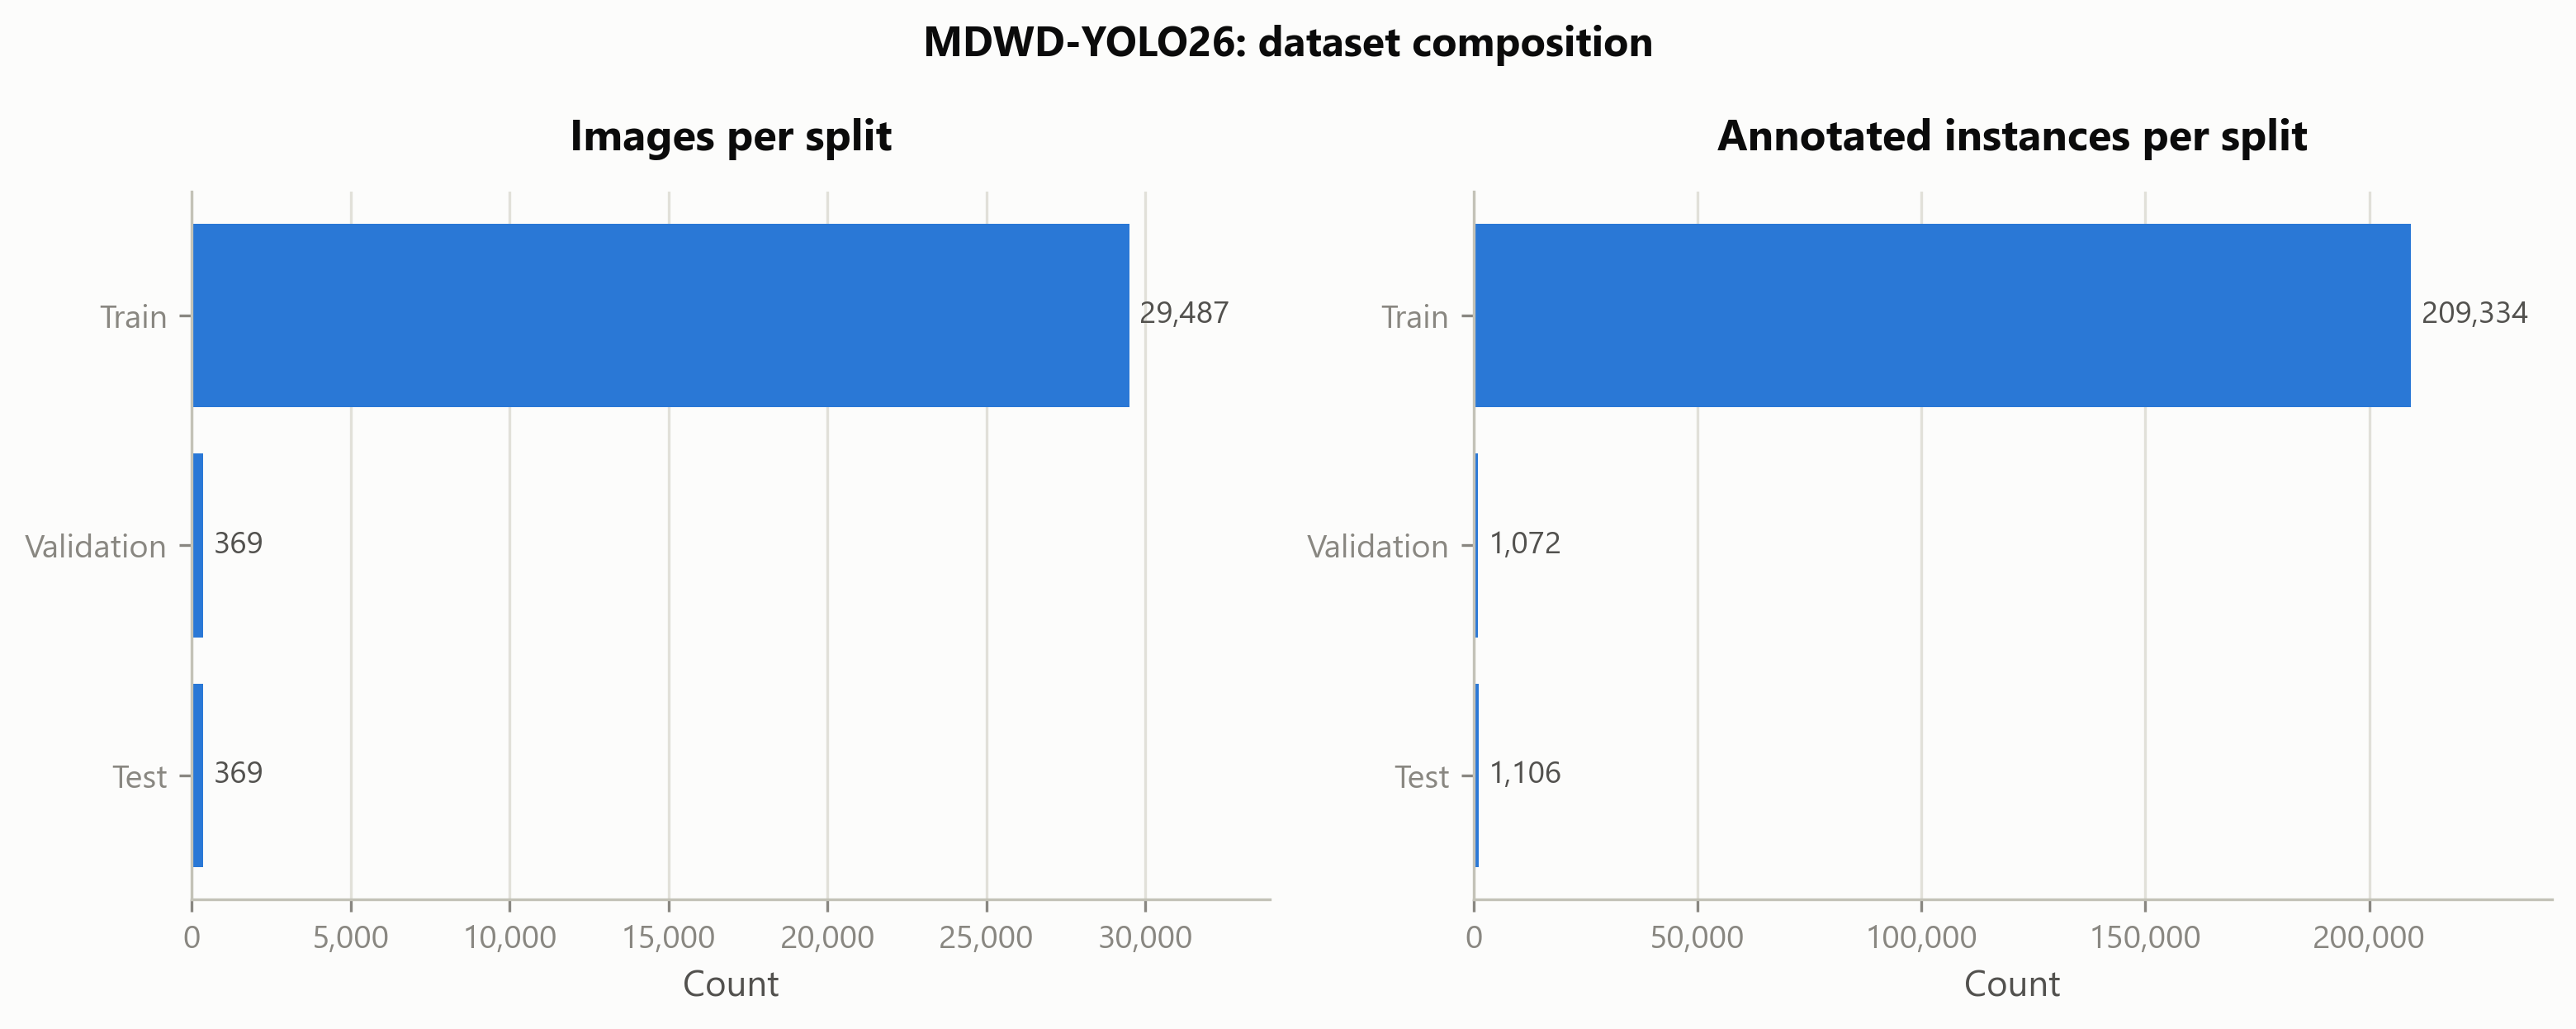

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,369.0,3.00,3.21,1.0,1.0,2.0,3.0,28.0
train,29487.0,7.10,4.23,0.0,4.0,6.0,9.0,42.0
valid,369.0,2.91,2.70,1.0,1.0,2.0,4.0,18.0


In [6]:
display(Image(filename=str(config.FIGURES_DIR / "fig01_dataset_composition.png"), width=940))

per_image = dataset_map.images.groupby("split")["n_boxes"].describe().round(2)
display(per_image)


## 5. Class balance

Class frequencies are shown overall (export level) and as within-split shares, which is
the fair comparison across splits of very different sizes. A skewed-but-consistent
profile across splits indicates the split preserved the class balance.


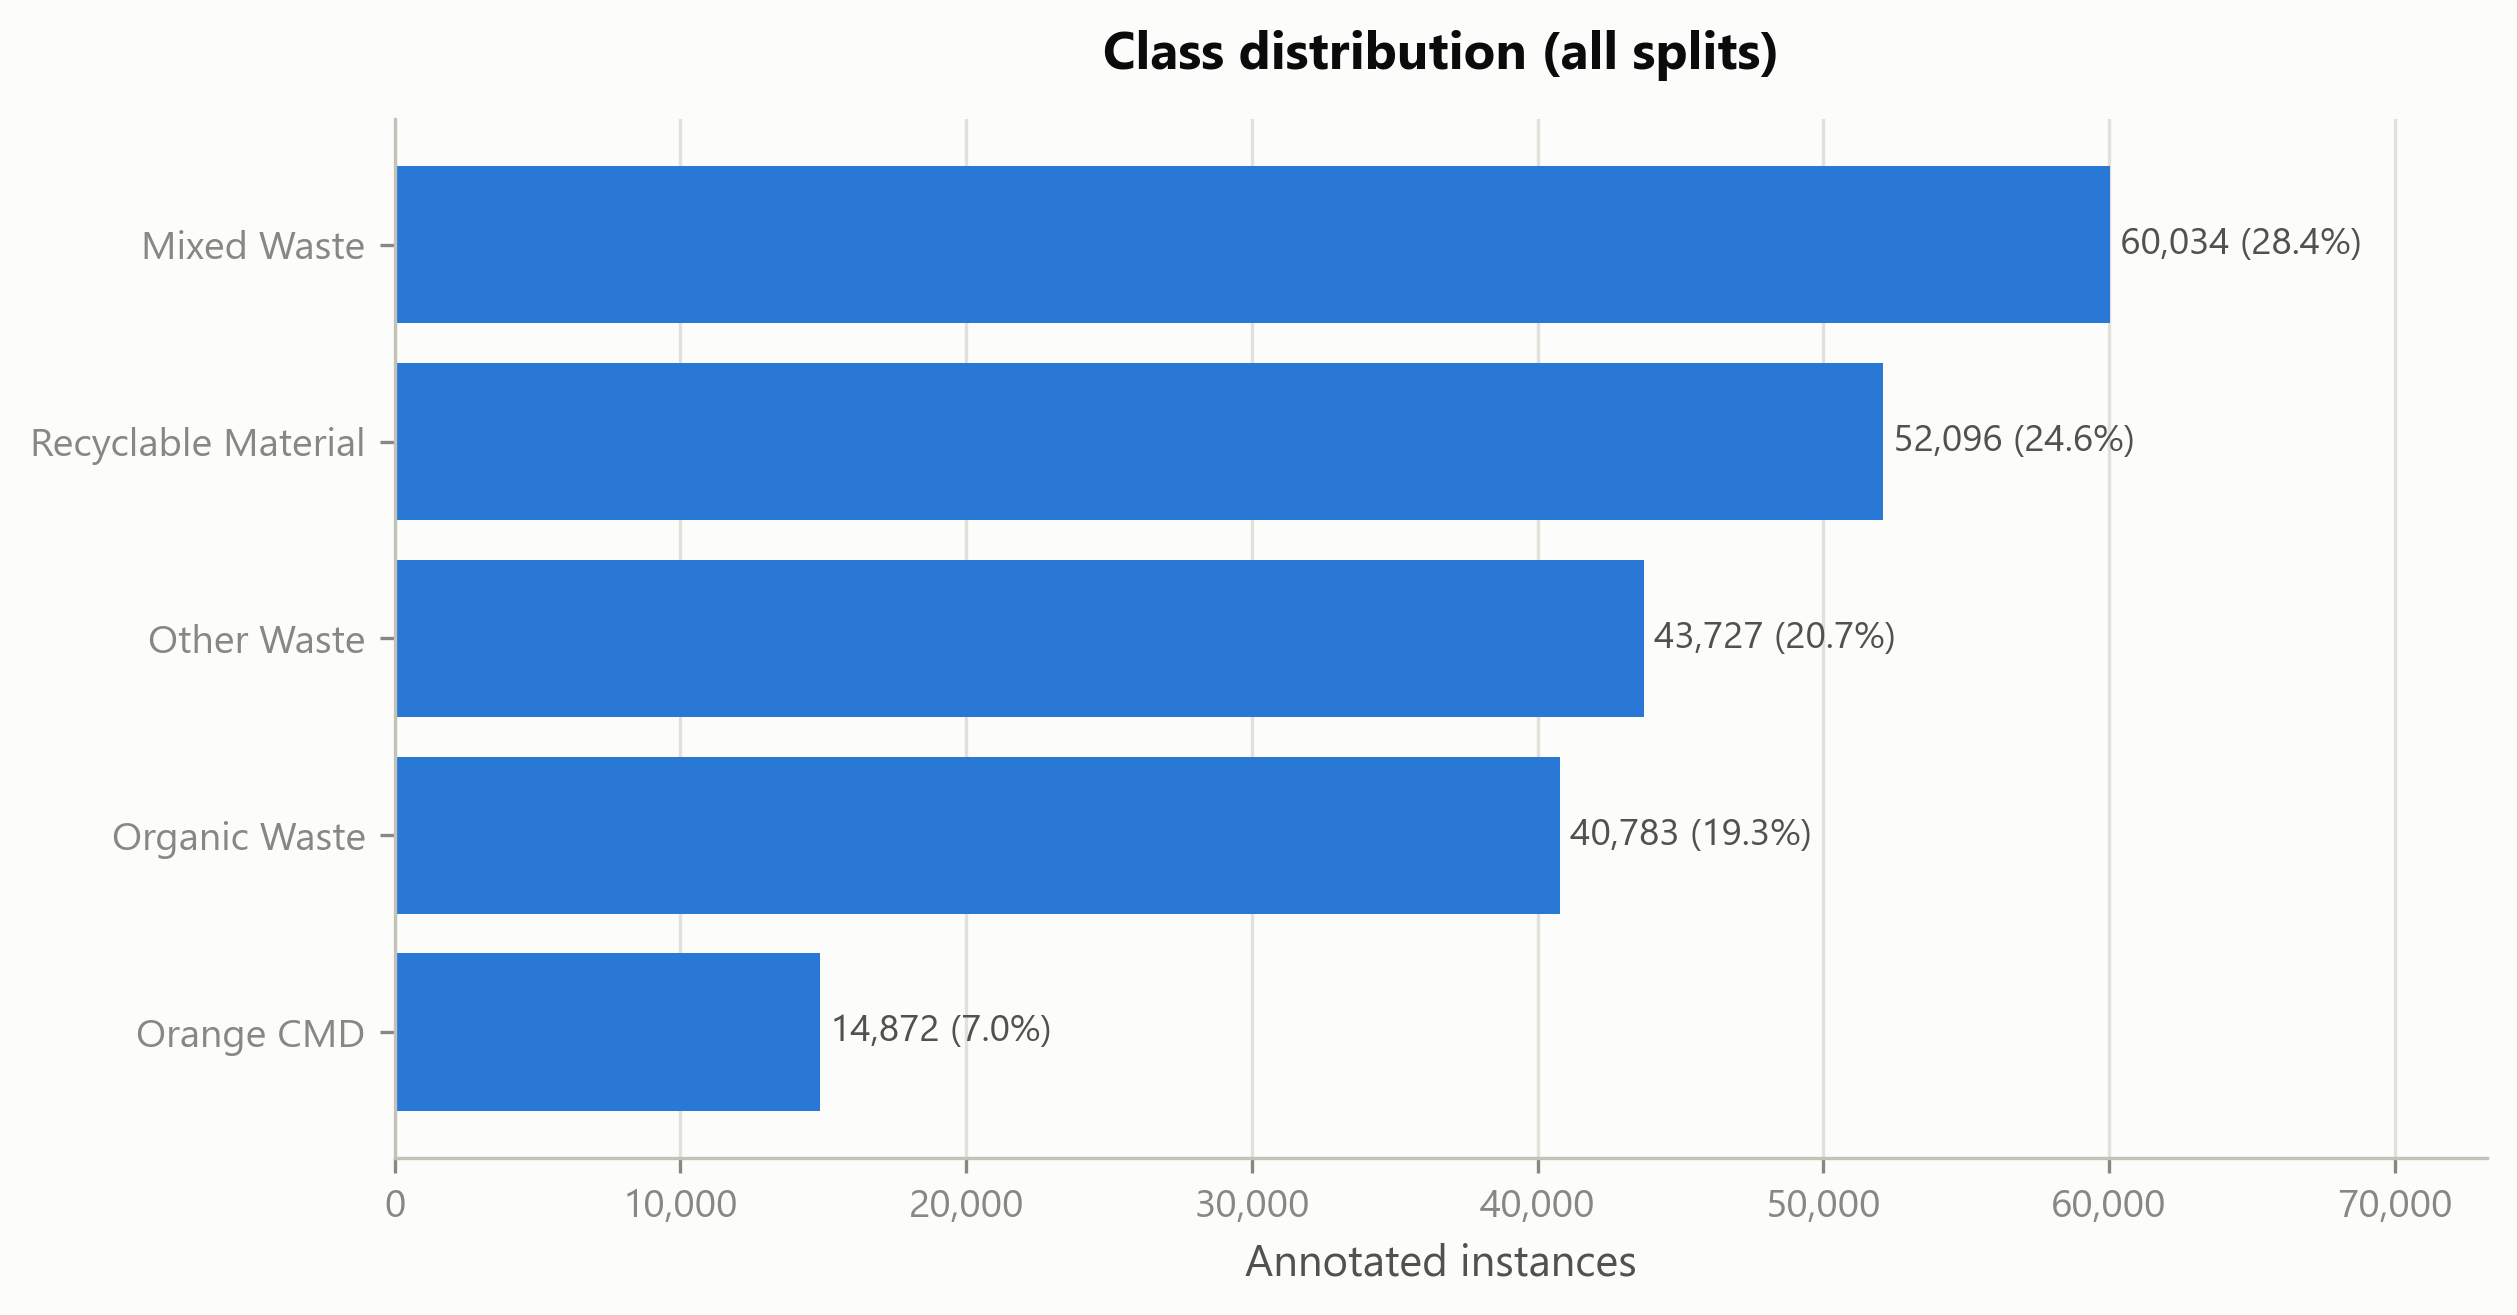

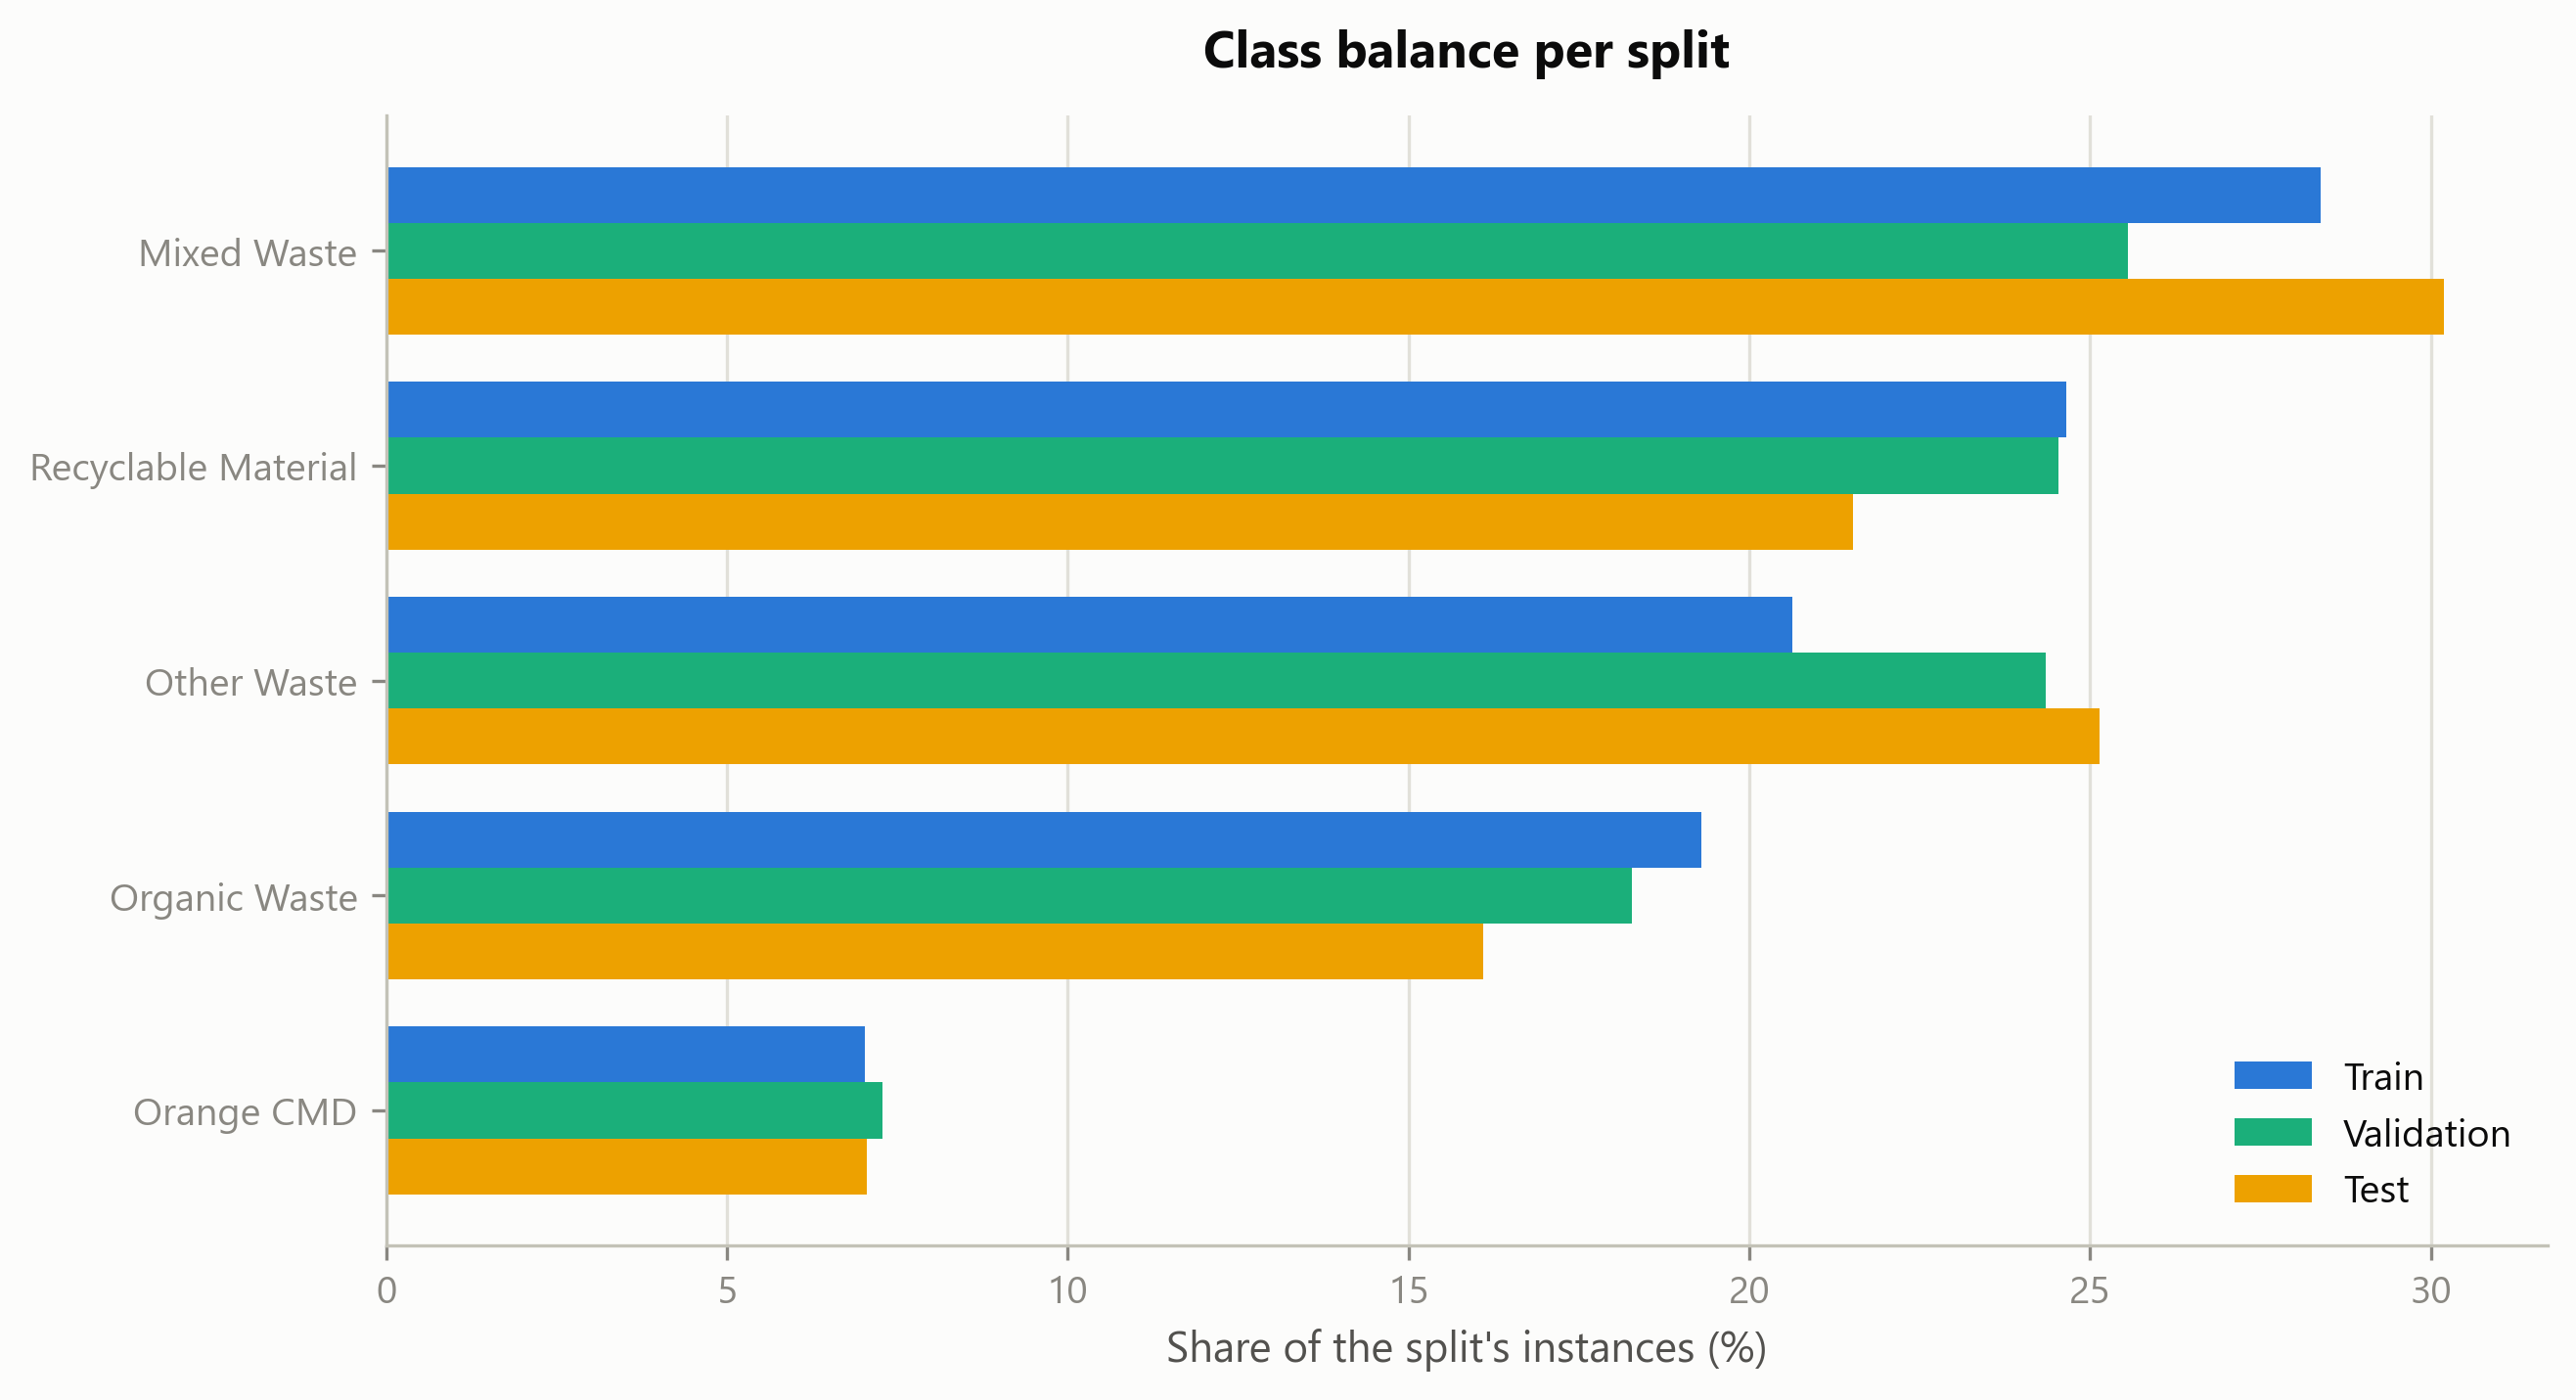

,class_name,instances,share_pct,train,valid,test
0,Mixed Waste,60034,28.38,59426,274,334
1,Recyclable Material,52096,24.63,51595,263,238
2,Other Waste,43727,20.67,43188,261,278
3,Organic Waste,40783,19.28,40409,196,178
4,Orange CMD,14872,7.03,14716,78,78


In [7]:
display(Image(filename=str(config.FIGURES_DIR / "fig02_class_distribution.png"), width=880))
display(Image(filename=str(config.FIGURES_DIR / "fig03_class_balance_per_split.png"), width=880))
display(stats.class_distribution(dataset_map))


## 6. Instance density

Domestic-waste scenes are typically multi-object: bags are put out in clusters, so the
instances-per-image distribution has a long right tail.


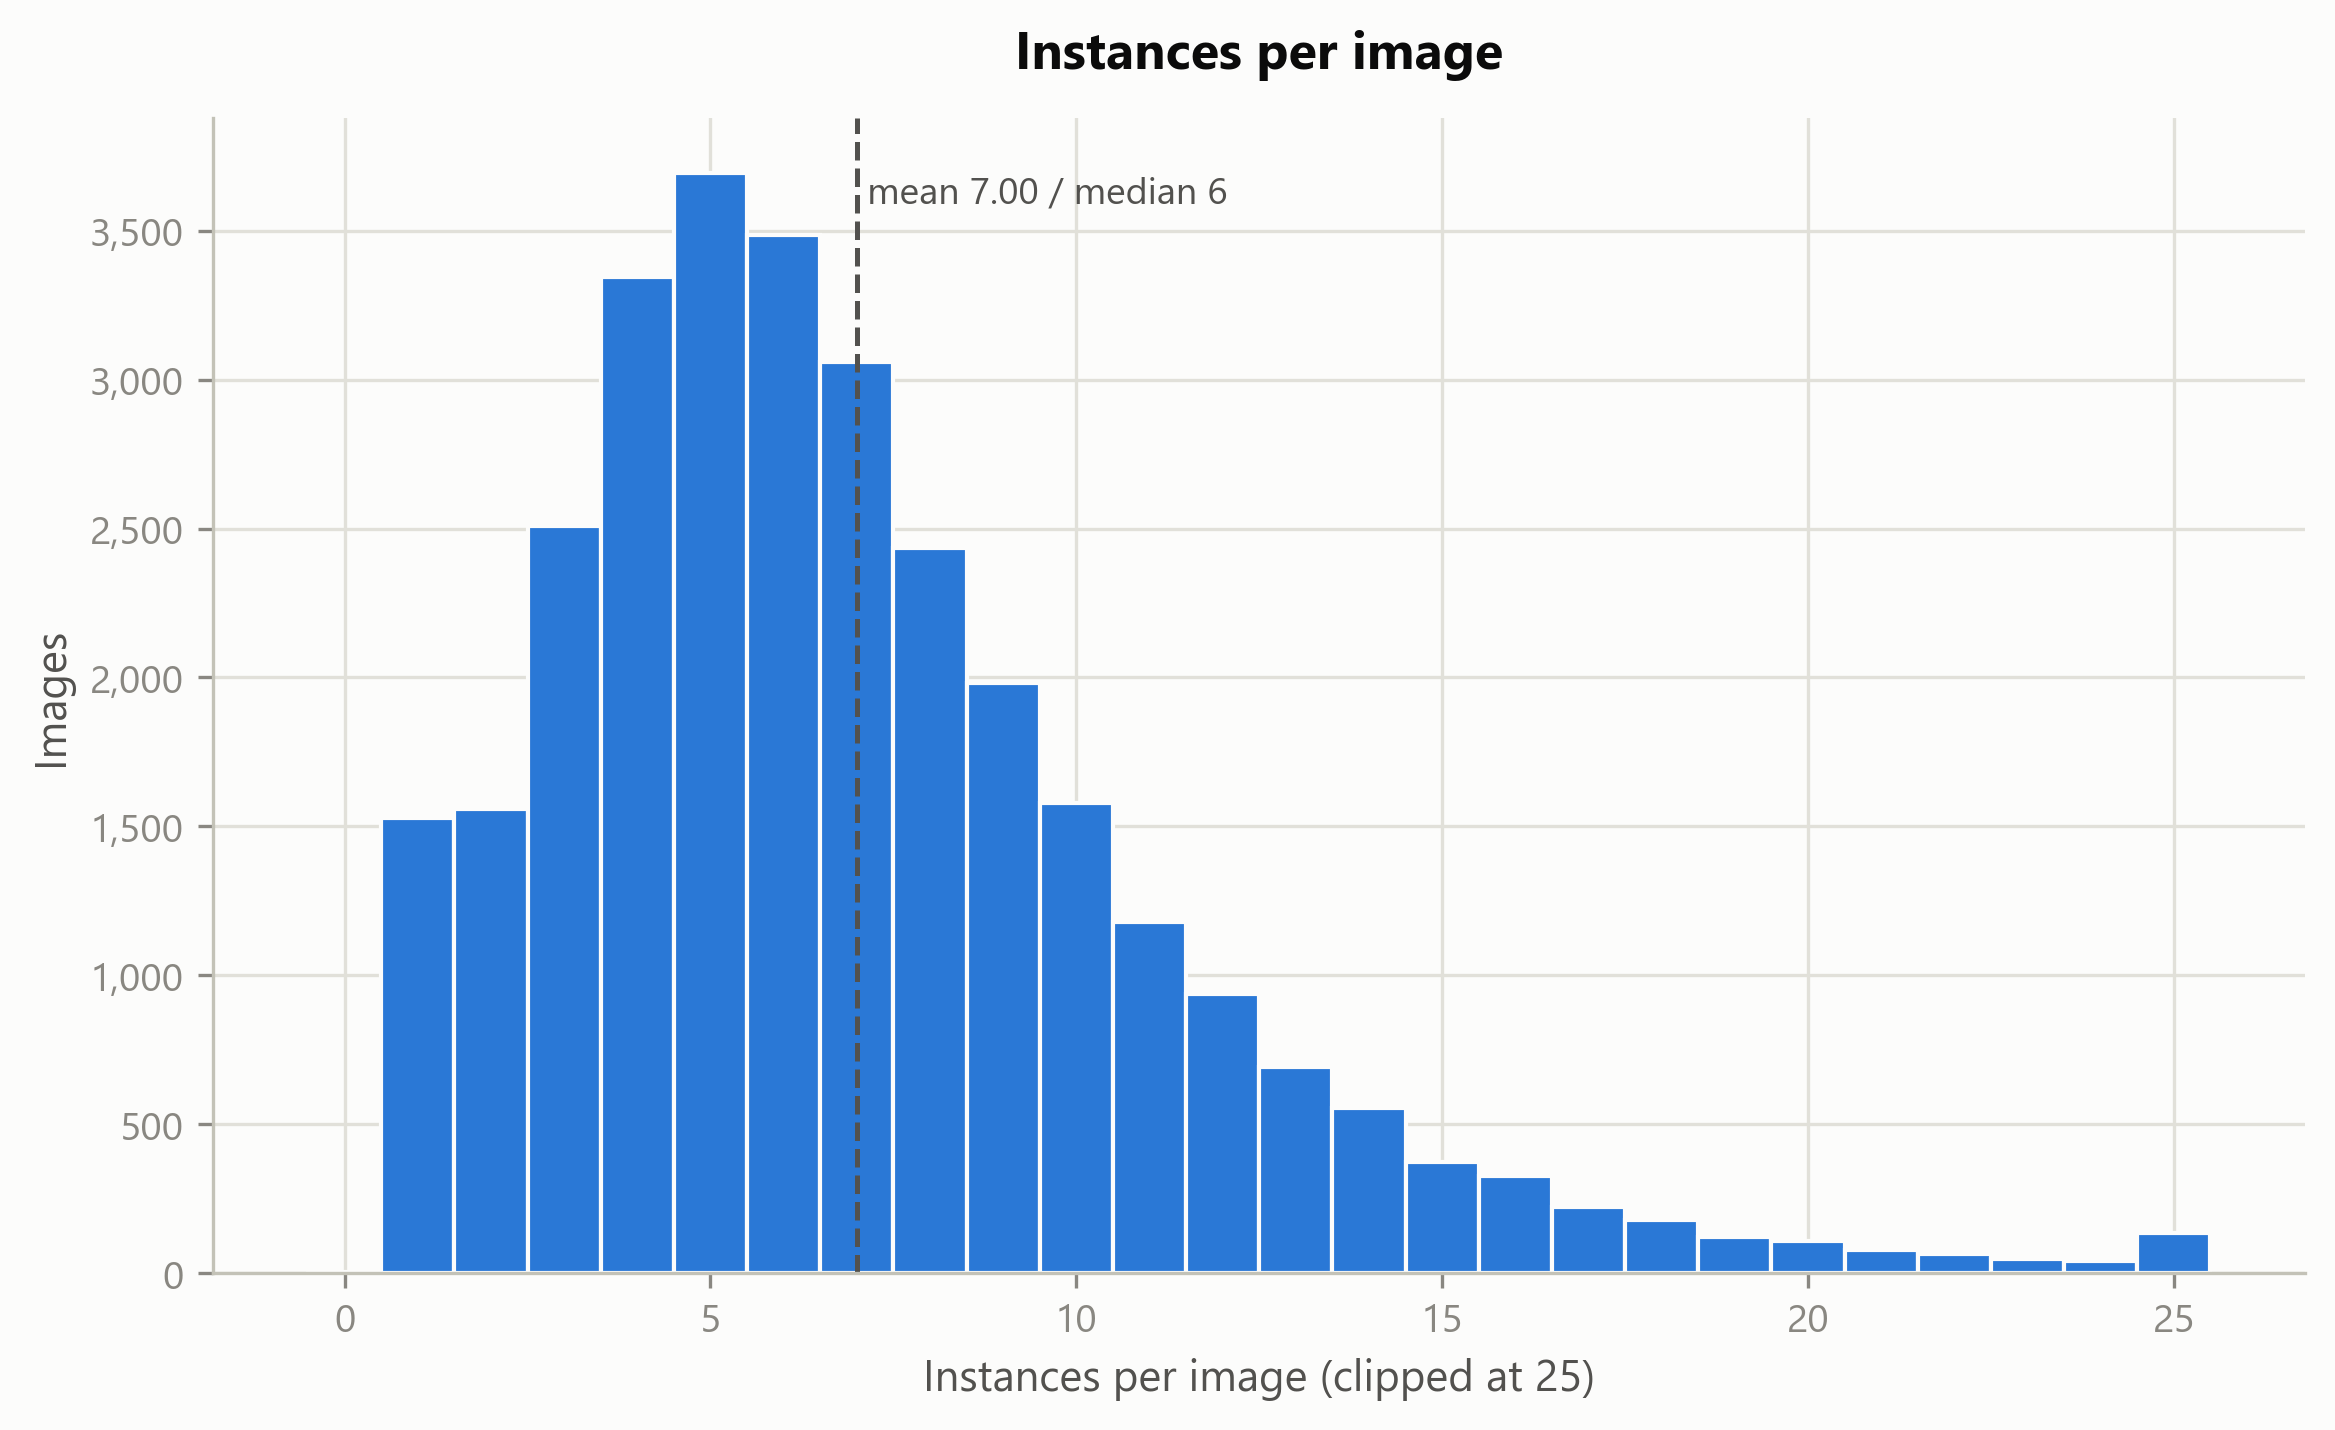

,images,mean,median,p95,max,zero-box images
0,30225,6.998,6.0,15.0,42,5


In [8]:
display(Image(filename=str(config.FIGURES_DIR / "fig04_instances_per_image.png"), width=880))

n_boxes = dataset_map.images["n_boxes"]
display(pd.DataFrame({
    "images": [len(n_boxes)],
    "mean": [round(n_boxes.mean(), 3)],
    "median": [n_boxes.median()],
    "p95": [n_boxes.quantile(0.95)],
    "max": [n_boxes.max()],
    "zero-box images": [(n_boxes == 0).sum()],
}))


## 7. Bounding-box geometry

Box area is reported as a fraction of the image (the export is uniformly 640×640, so
fractions map directly to pixel areas) on a log axis; aspect ratio uses a log axis
centred on 1.0 (square). The COCO small/medium/large partition (≤32², ≤96² px) shows
how much of each class sits in the hard small-object regime.


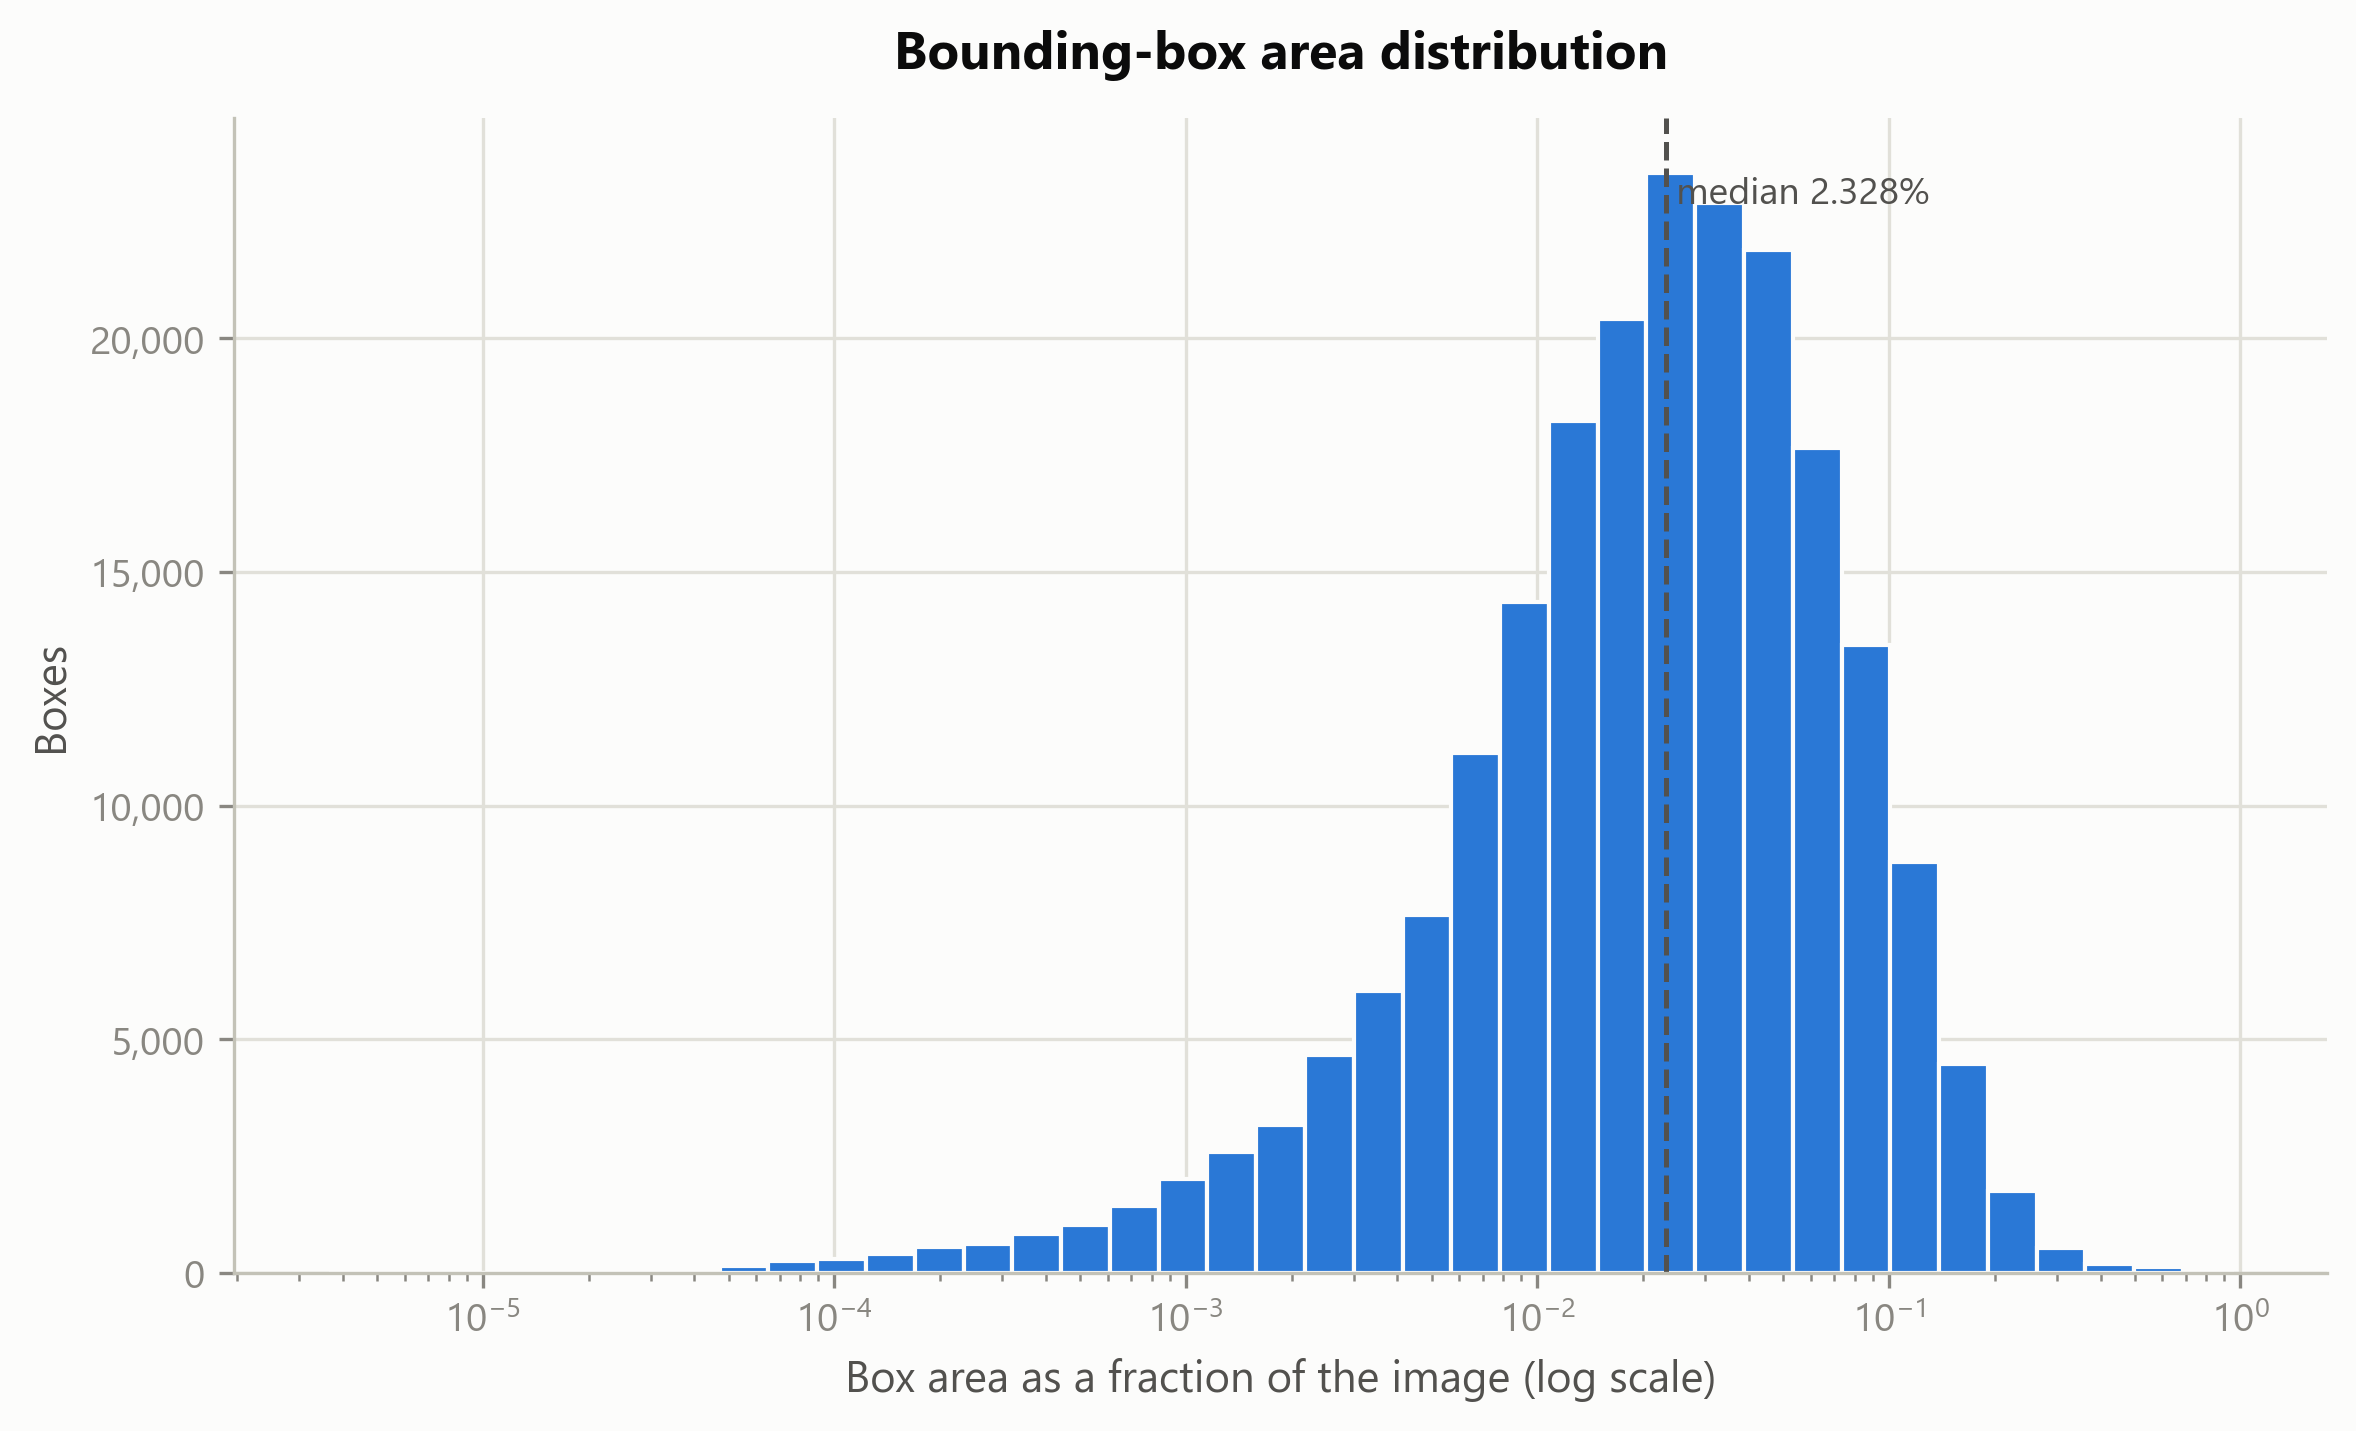

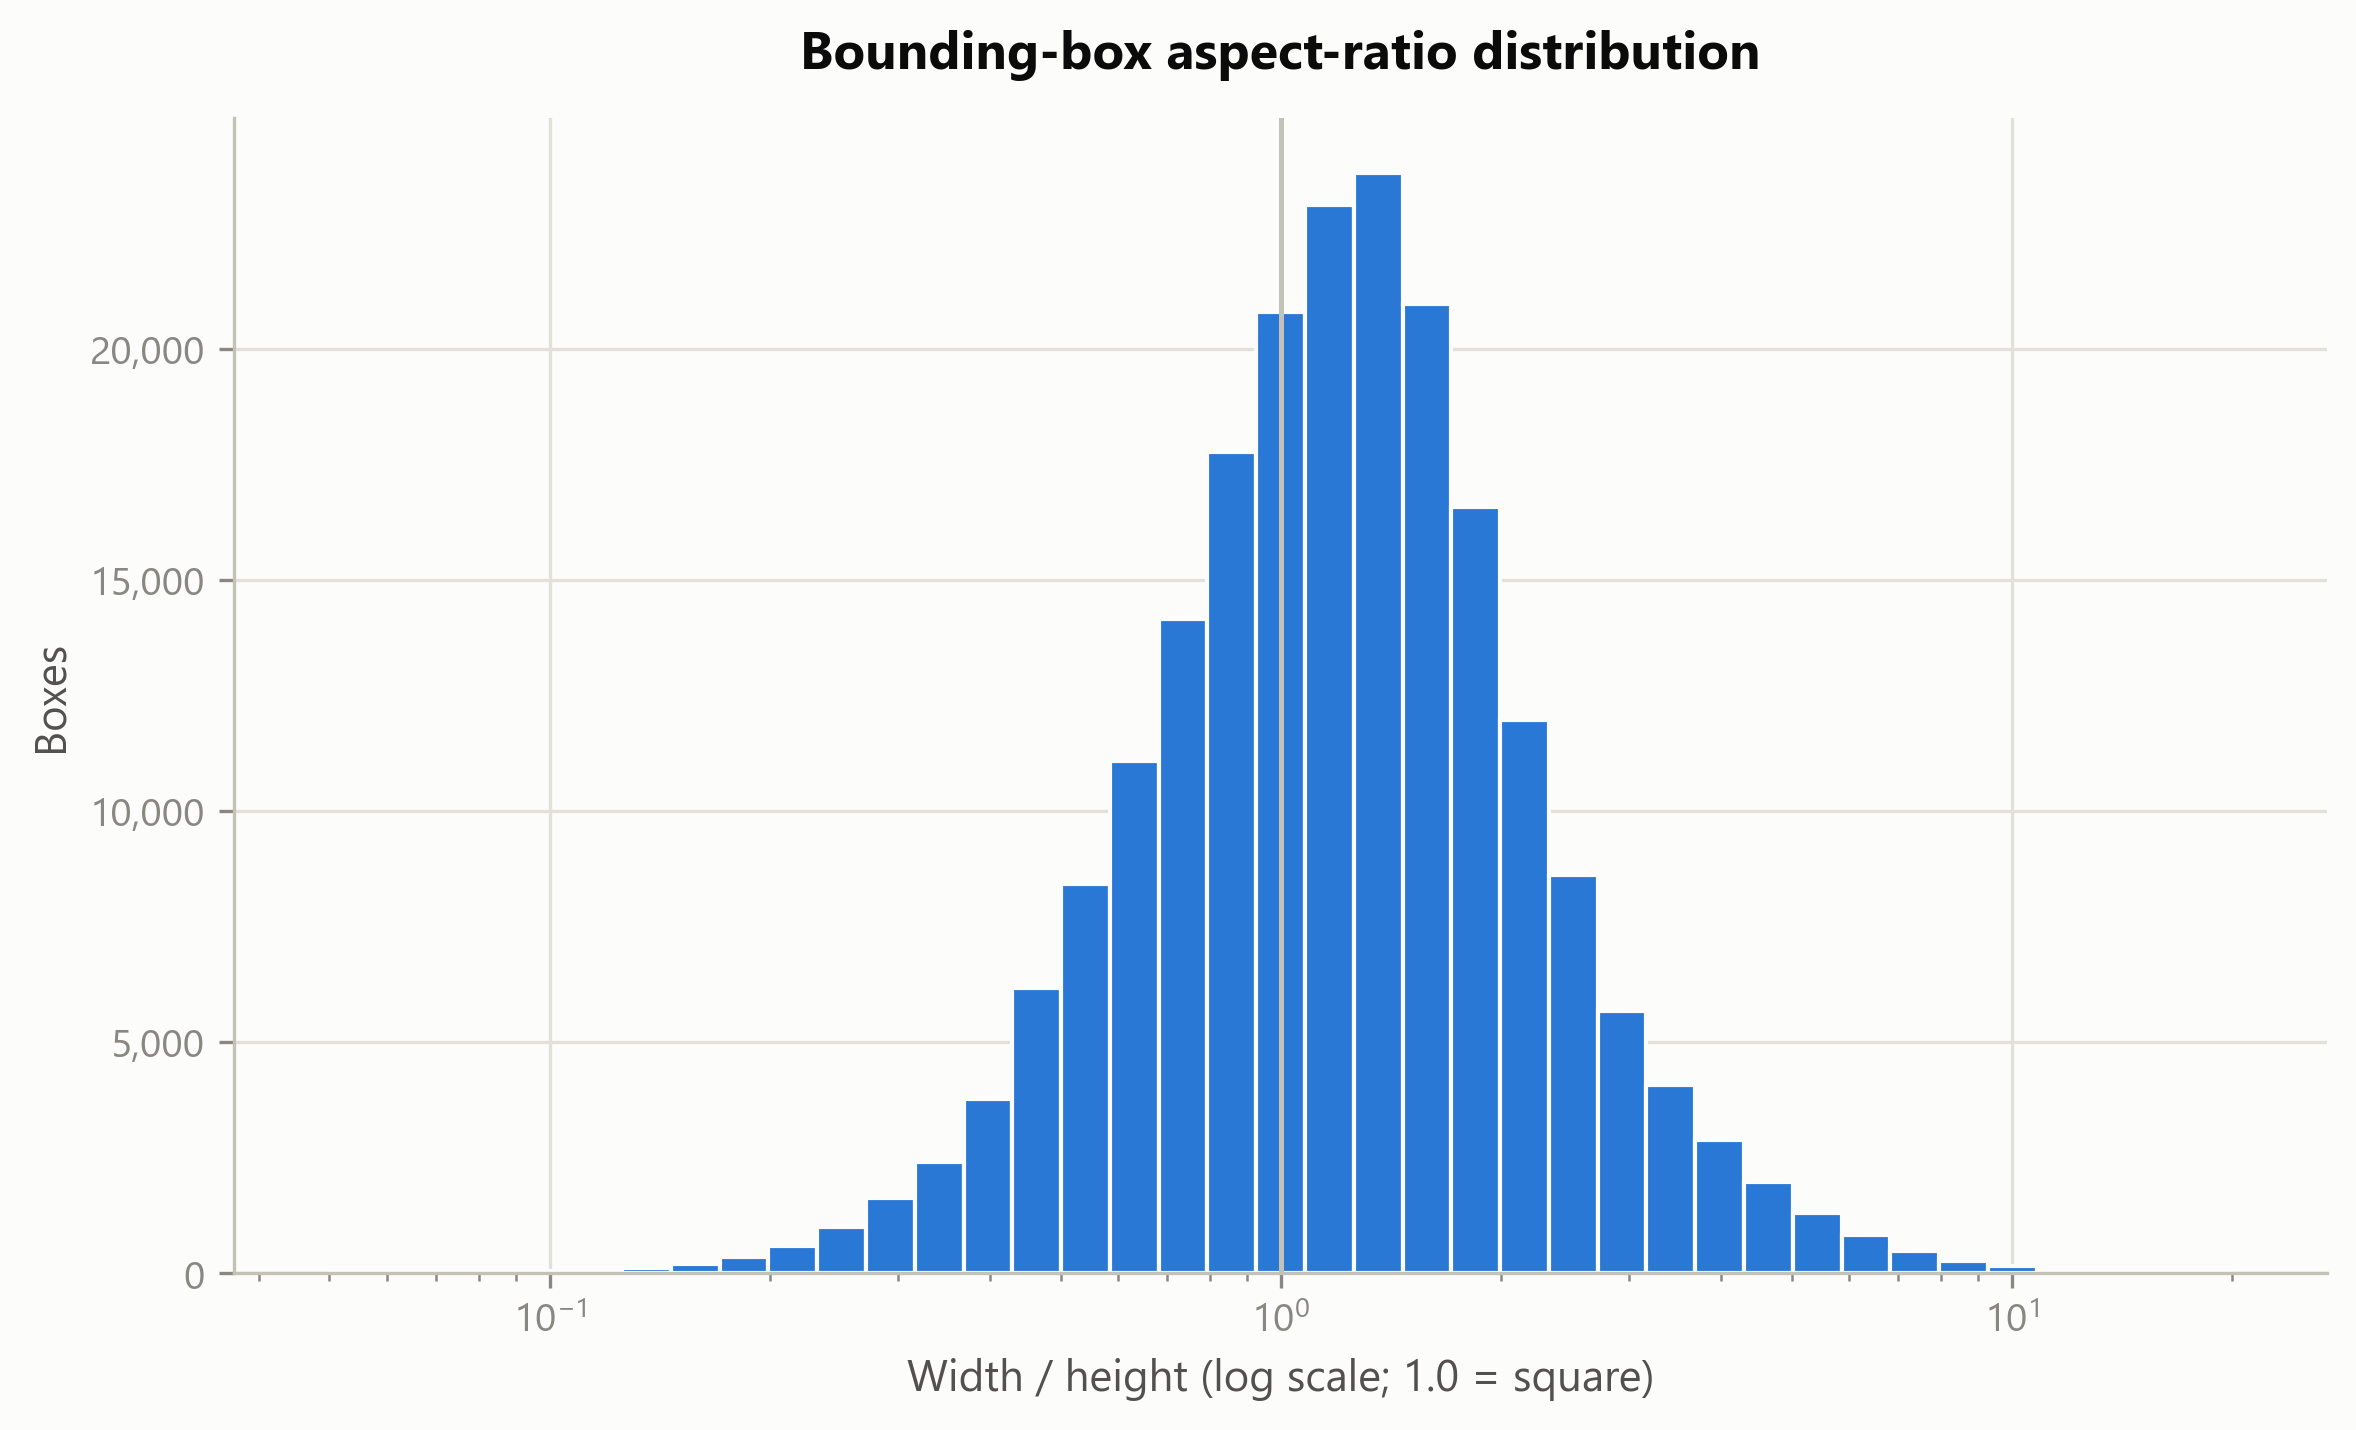

,metric,mean,p05,p25,median,p75,p95,min,max
0,area_frac,0.03765,0.00161,0.00984,0.02328,0.04863,0.11977,0.00000,0.94465
1,aspect_ratio,1.46516,0.43415,0.81548,1.21106,1.74194,3.34091,0.00182,686.00000
2,pixel_area,15421.06840,660.00000,4030.00000,9533.75000,19919.25000,49056.00000,1.50000,386927.65121


In [9]:
display(Image(filename=str(config.FIGURES_DIR / "fig05_bbox_area.png"), width=880))
display(Image(filename=str(config.FIGURES_DIR / "fig06_bbox_aspect_ratio.png"), width=880))
display(stats.bbox_geometry(dataset_map))


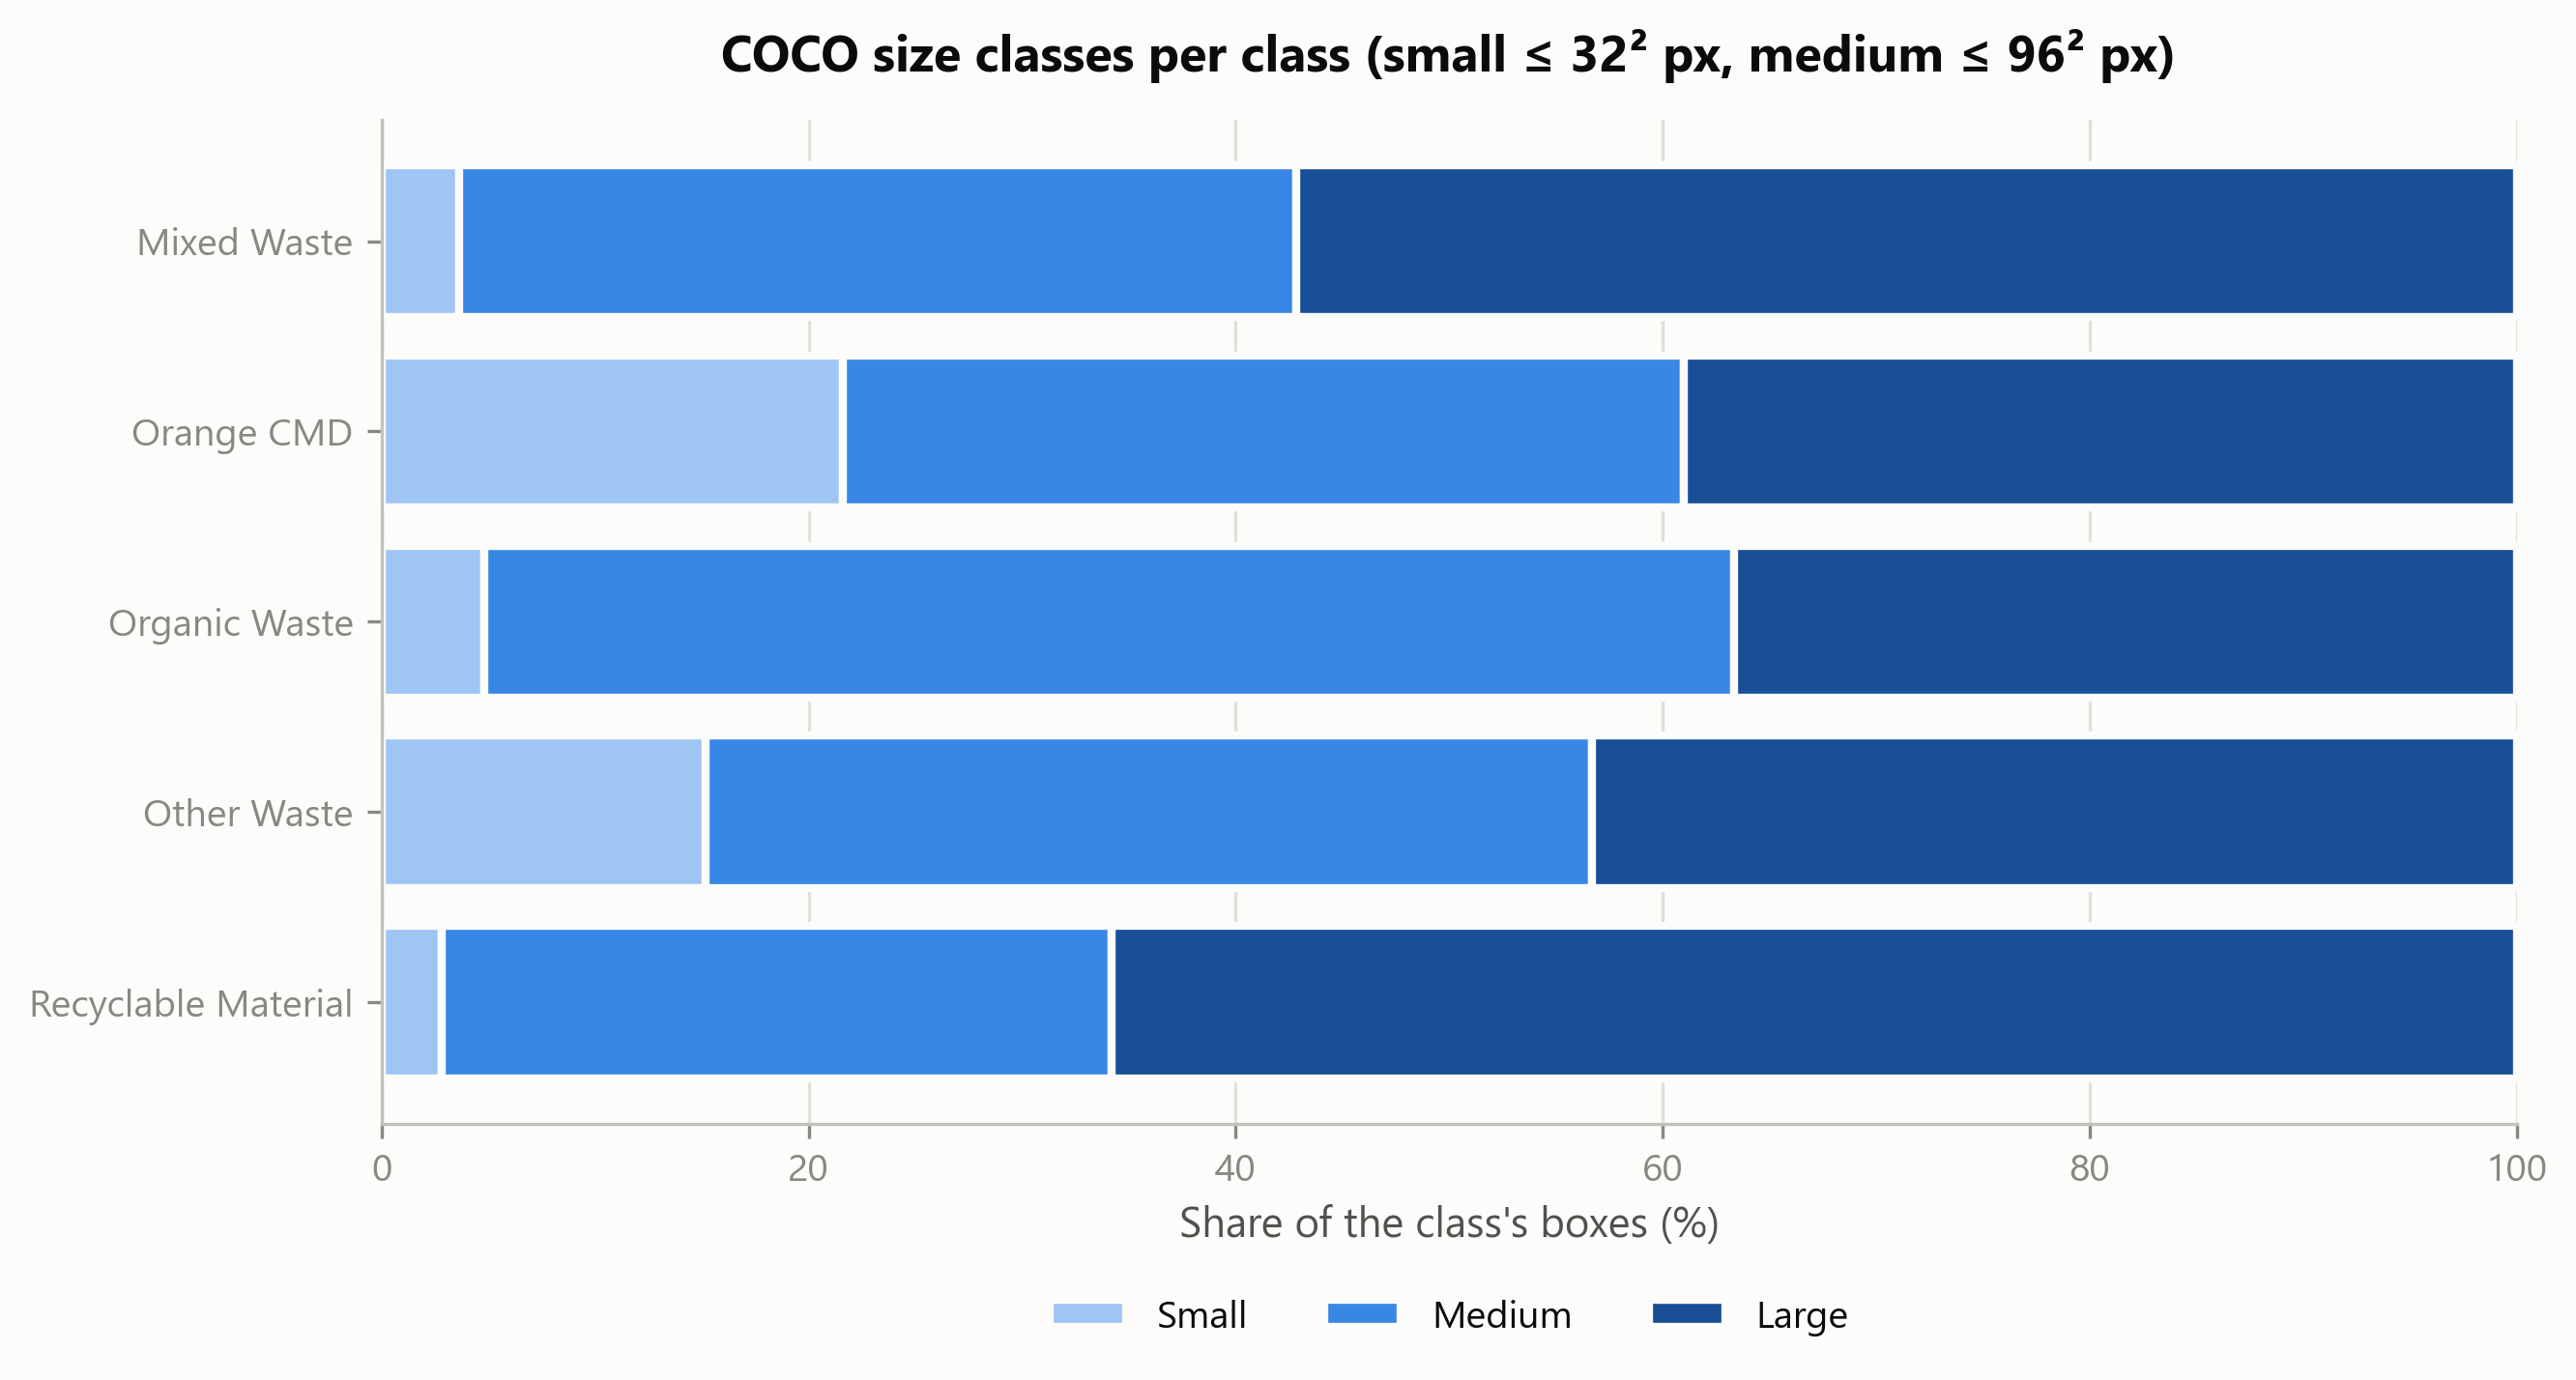

size_class,class_name,small,medium,large
0,Mixed Waste,2182,23533,34319
1,Orange CMD,3214,5859,5799
2,Organic Waste,1960,23869,14954
3,Other Waste,6643,18152,18932
4,Recyclable Material,1463,16339,34294


In [10]:
display(Image(filename=str(config.FIGURES_DIR / "fig07_coco_size_classes.png"), width=880))
display(stats.size_class_distribution(dataset_map))


## 8. Resolutions and spatial layout

The Roboflow pre-processing resizes every image to 640×640 (stretch), so the resolution
chart is expected to be degenerate — it is kept as evidence of that uniformity. The
centre-density map shows where annotated objects sit in the frame; kerbside waste
clusters towards the lower-central band of the image.


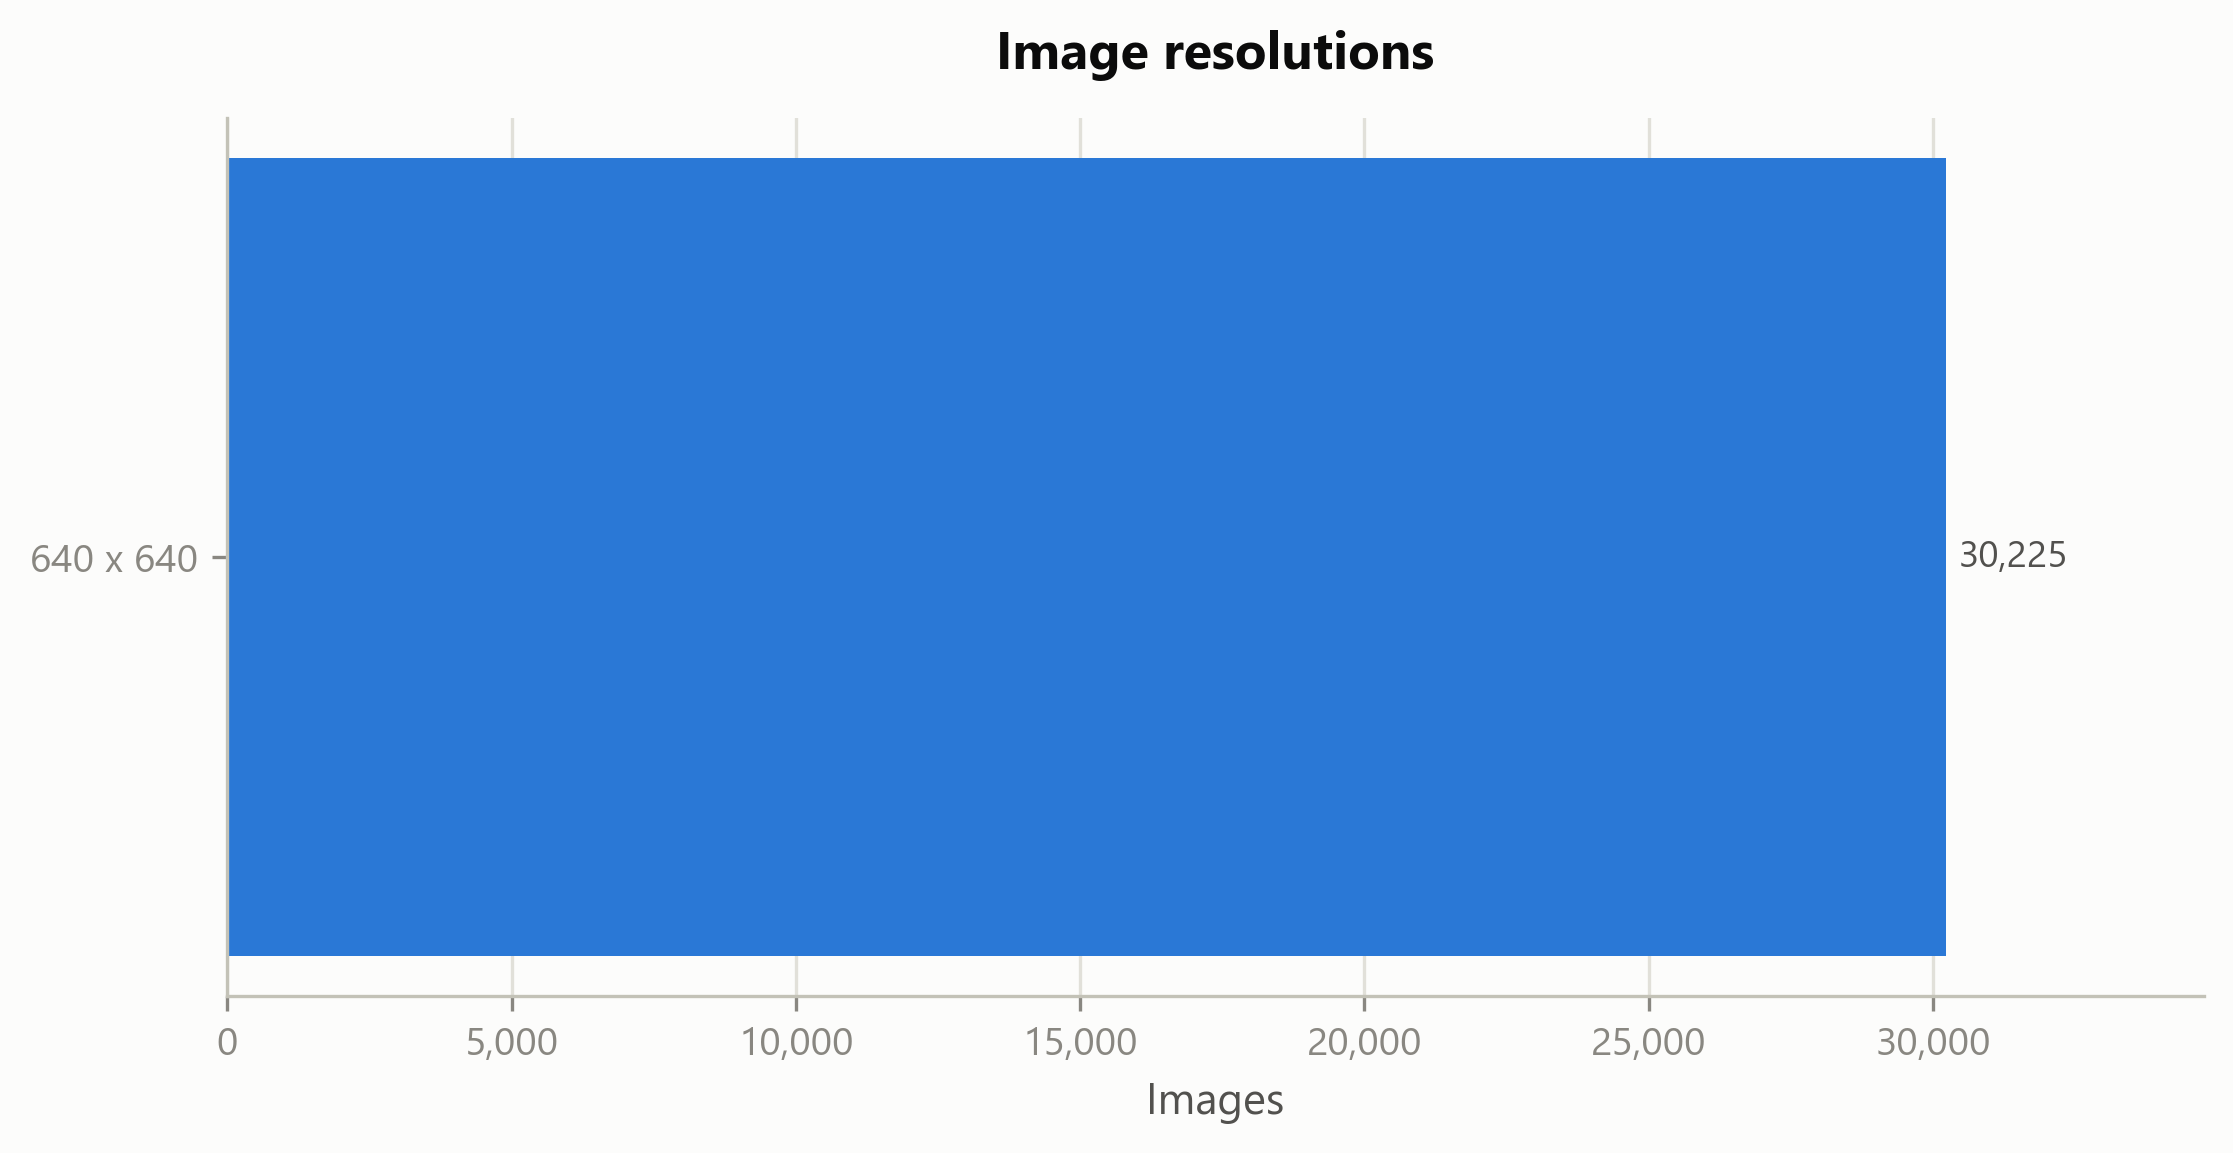

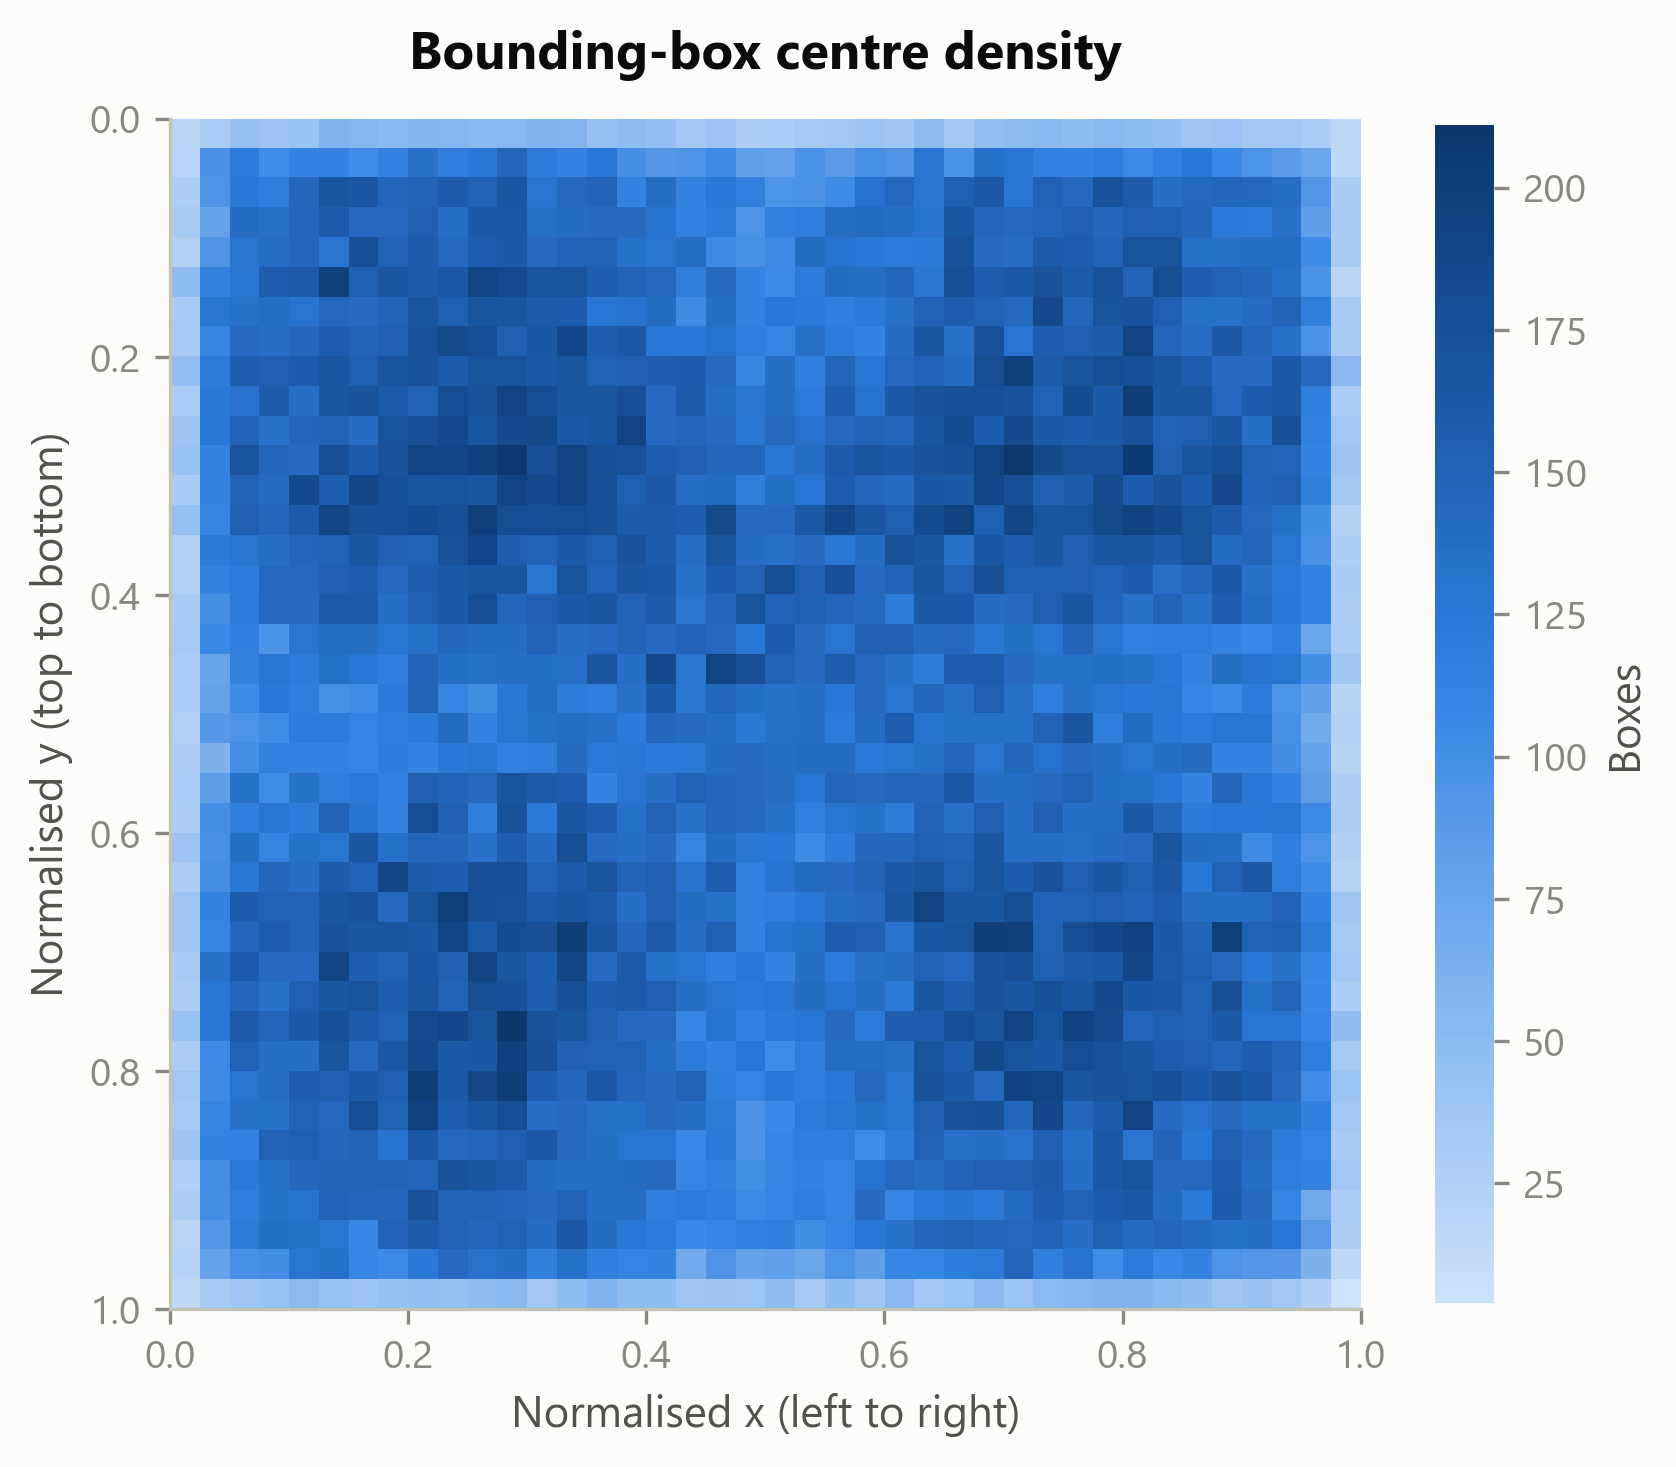

In [11]:
display(Image(filename=str(config.FIGURES_DIR / "fig08_image_resolutions.png"), width=800))
display(Image(filename=str(config.FIGURES_DIR / "fig09_box_centre_density.png"), width=640))


## 9. Class co-occurrence

How often two classes are annotated in the same image (diagonal = images containing the
class at all). Waste is put out in mixed batches, so strong off-diagonal mass is
expected between the frequent classes.


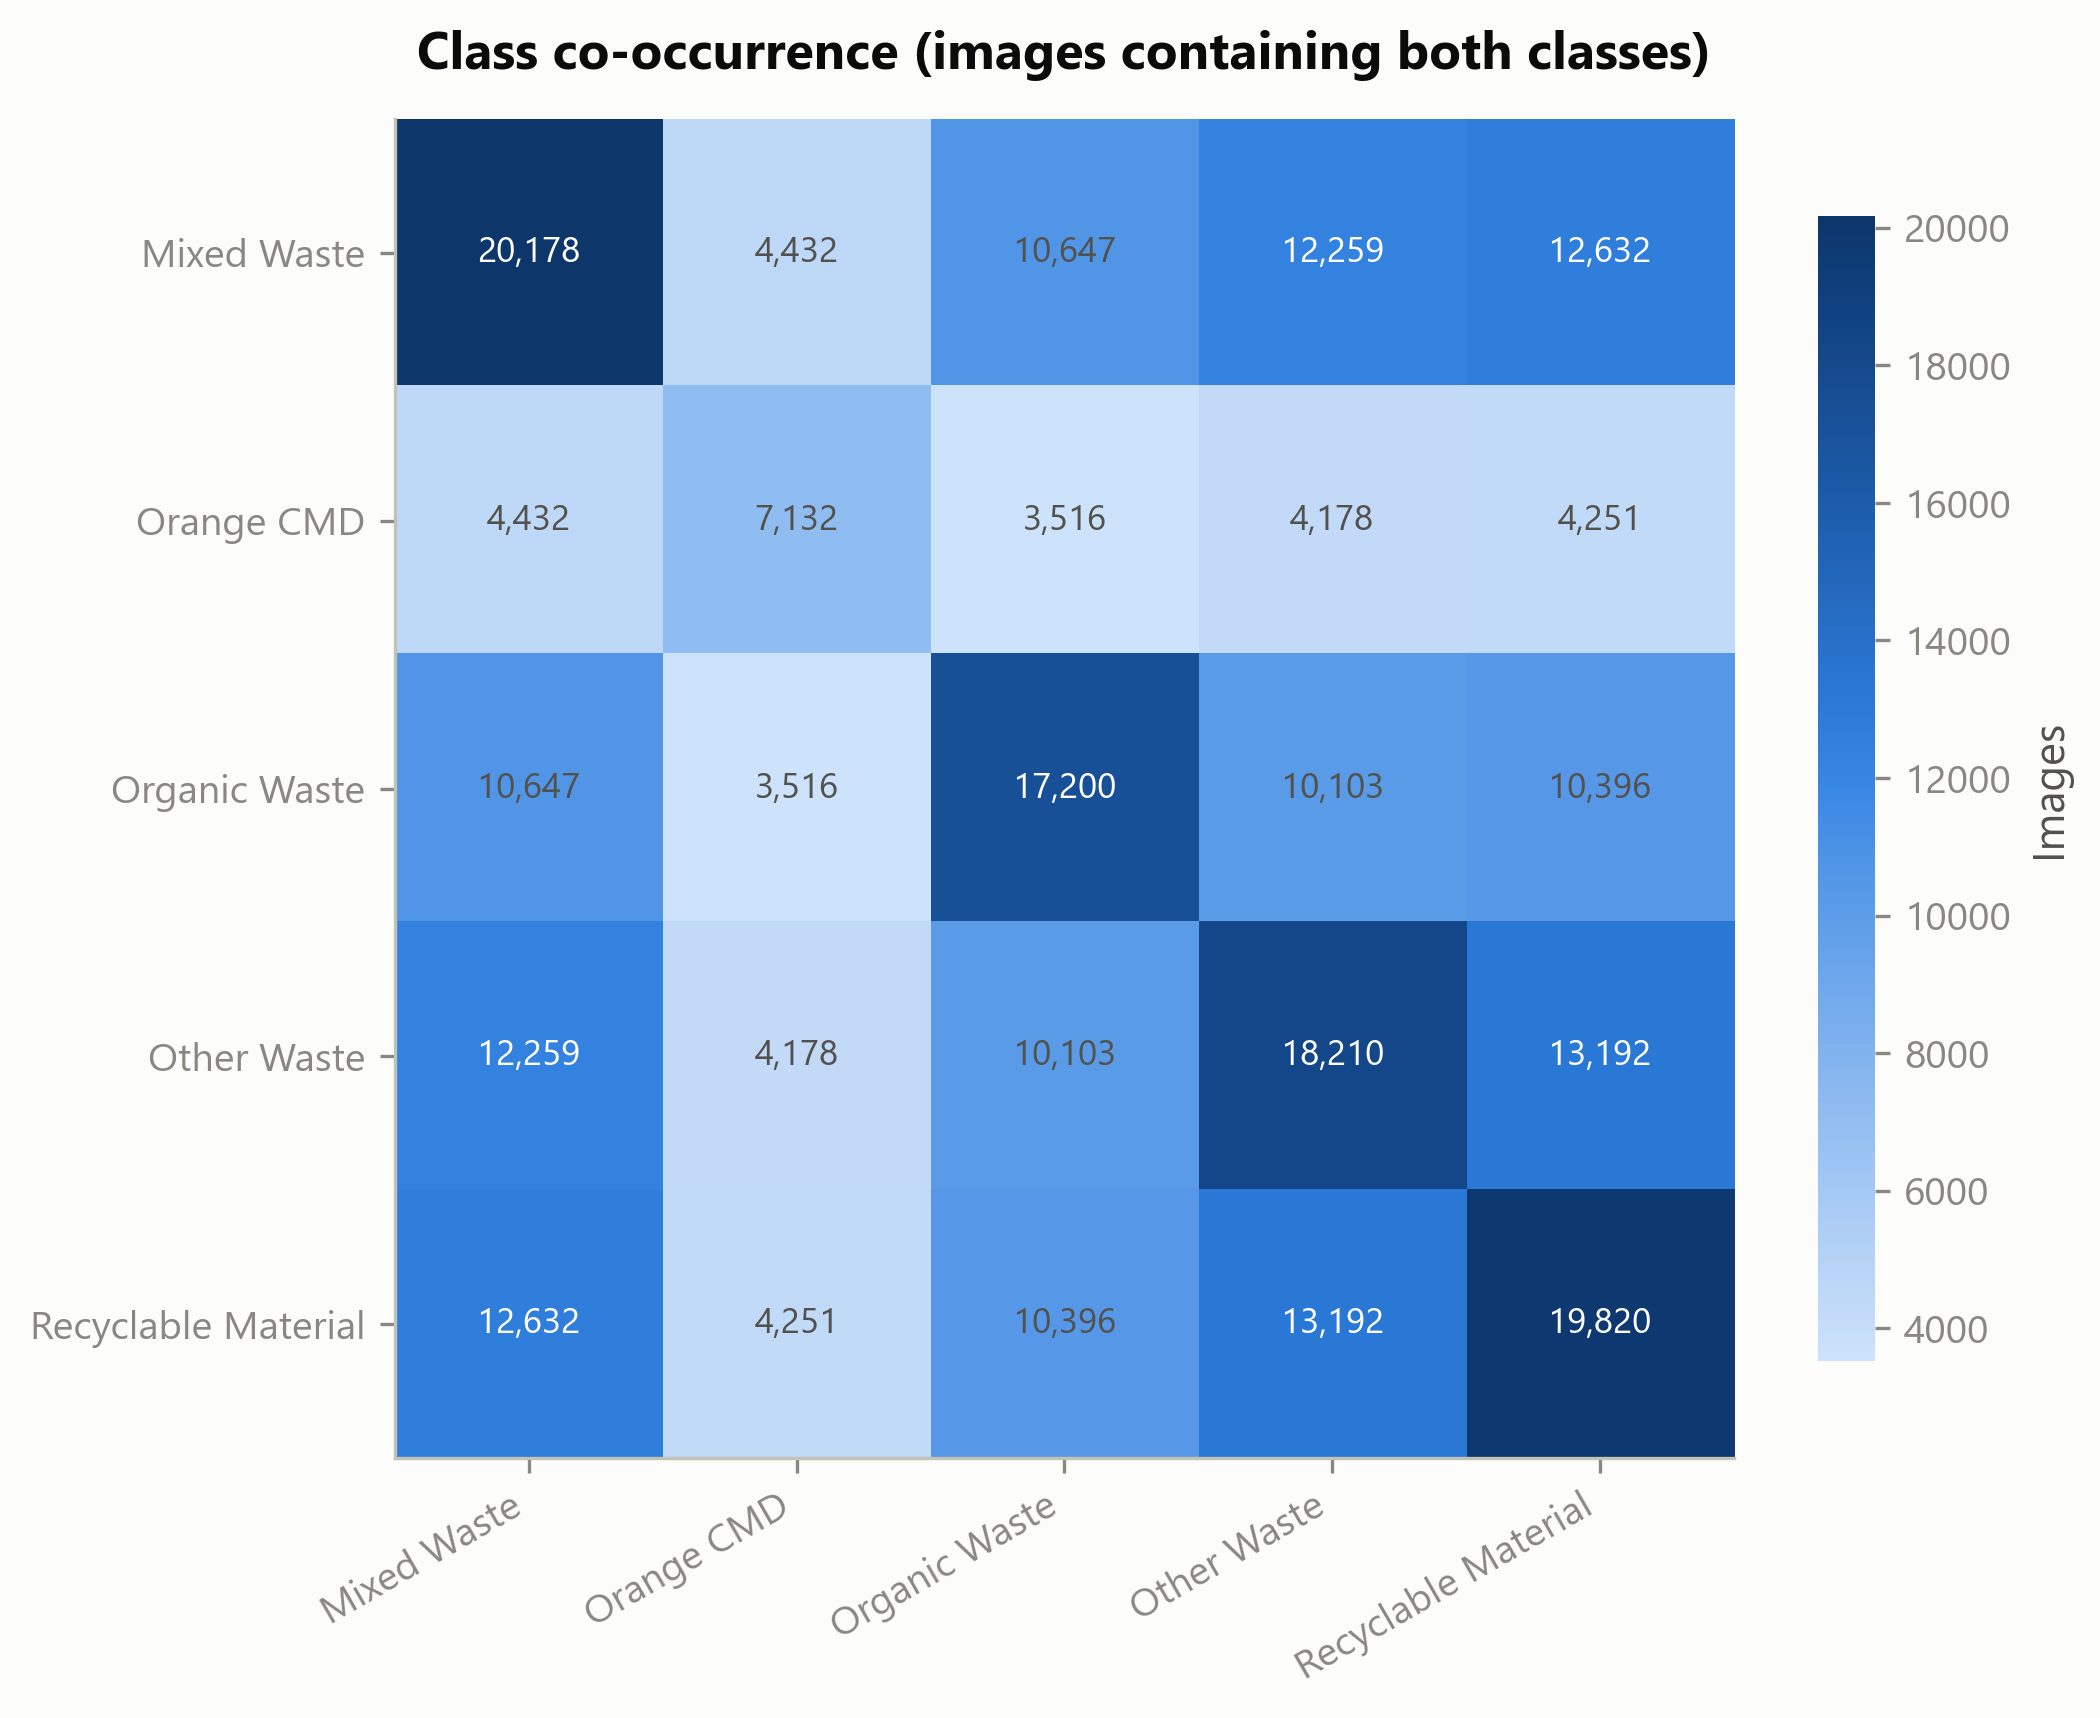

,Mixed Waste,Orange CMD,Organic Waste,Other Waste,Recyclable Material
Mixed Waste,20178,4432,10647,12259,12632
Orange CMD,4432,7132,3516,4178,4251
Organic Waste,10647,3516,17200,10103,10396
Other Waste,12259,4178,10103,18210,13192
Recyclable Material,12632,4251,10396,13192,19820


In [12]:
display(Image(filename=str(config.FIGURES_DIR / "fig10_class_cooccurrence.png"), width=760))
display(stats.class_cooccurrence(dataset_map))


## 10. Annotated samples

A fixed-seed sample of annotated images per split, drawn with the same class-to-colour
assignment as the charts (via `visualise_samples.draw_boxes`). Full-size renders for all
splits are exported by `visualise_samples.py` to
`Documents/MDWD-EDA/SampleAnnotationImages/`.


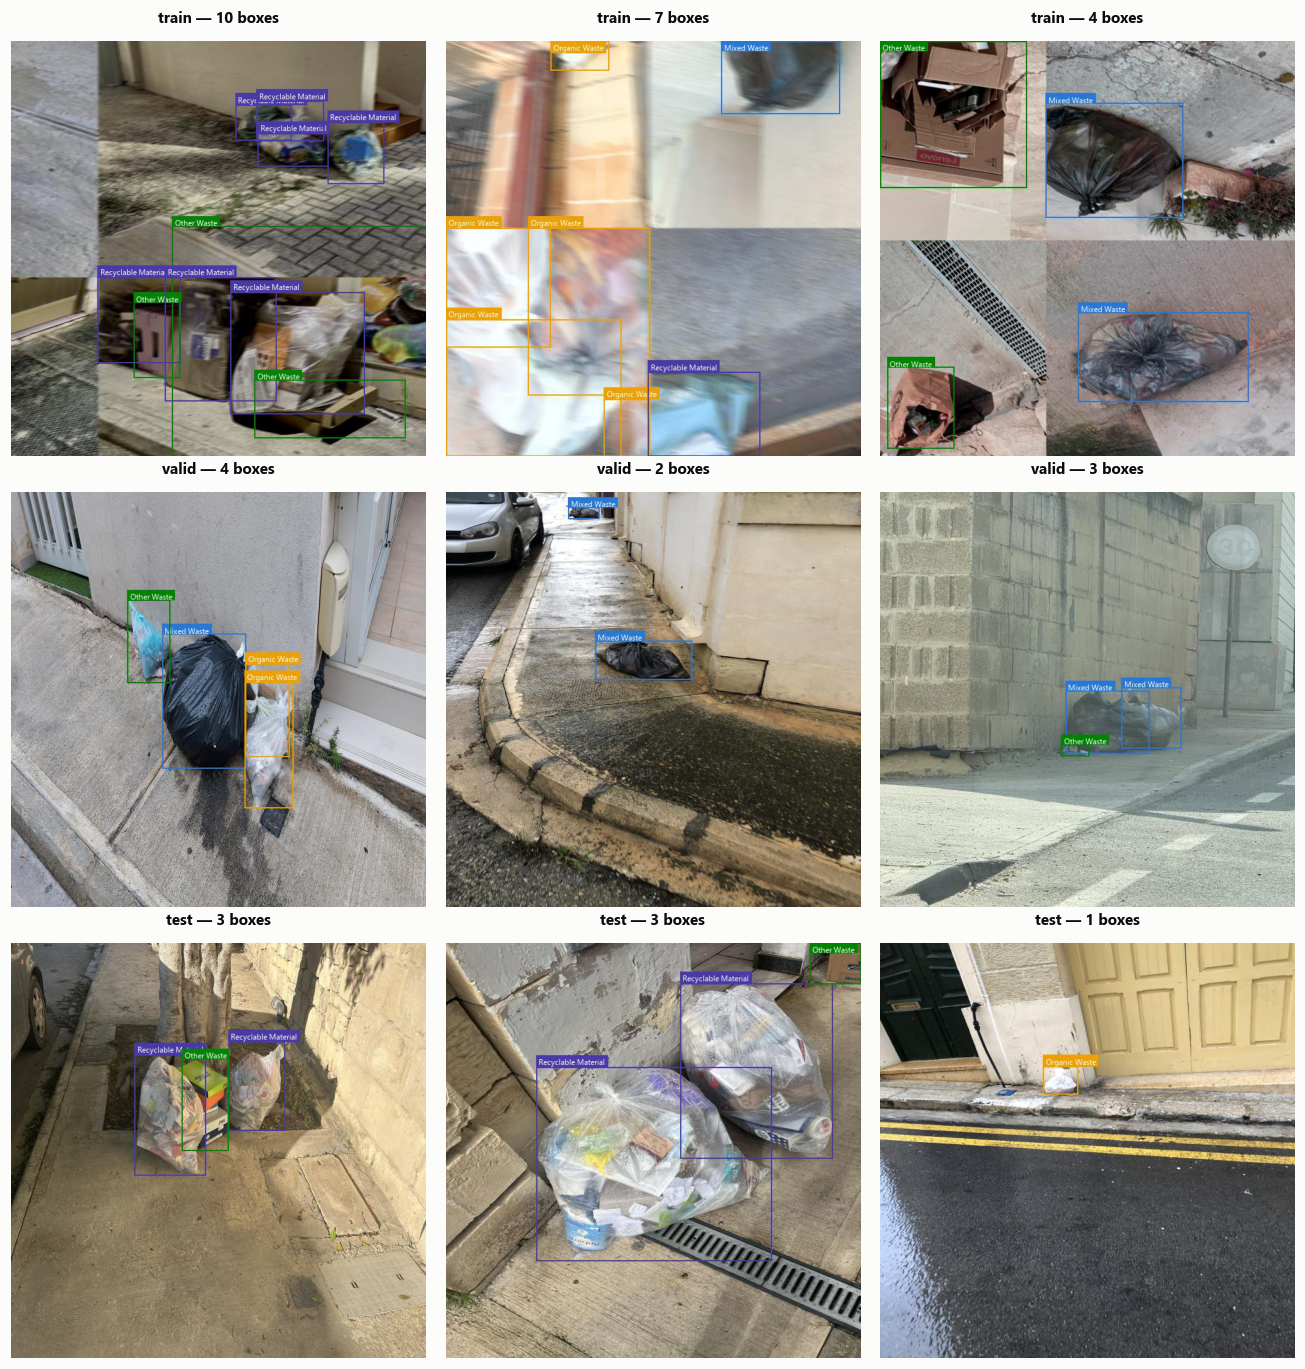

In [13]:
import random

from visualise_samples import draw_boxes  # noqa: E402  (sibling module)

SAMPLES_PER_SPLIT = 3
rng = random.Random(42)
variant_dir = config.variant_dir(VARIANT)

fig, axes = plt.subplots(len(config.SPLITS), SAMPLES_PER_SPLIT, figsize=(12, 12.5))
scratch = config.SAMPLES_DIR / "_notebook_preview"
for row, split in enumerate(config.SPLITS):
    candidates = dataset_map.images[
        (dataset_map.images["split"] == split) & (dataset_map.images["n_boxes"] > 0)
    ]
    chosen = candidates.sample(n=min(SAMPLES_PER_SPLIT, len(candidates)),
                               random_state=rng.randint(0, 2**31))
    for col, (_, record) in enumerate(chosen.iterrows()):
        image_path = variant_dir / split / "images" / record["file_name"]
        boxes = dataset_map.boxes[(dataset_map.boxes["split"] == split)
                                  & (dataset_map.boxes["file_name"] == record["file_name"])]
        preview_path = scratch / f"{split}_{col}.jpg"
        draw_boxes(image_path, boxes, dataset_map.class_names, preview_path)
        axes[row, col].imshow(plt.imread(preview_path))
        axes[row, col].set_title(f"{split} — {record['n_boxes']} boxes", fontsize=10)
        axes[row, col].axis("off")
fig.tight_layout()
plt.show()


## 11. Summary and exported artefacts

Headline numbers, followed by every artefact this notebook regenerates — for direct
inclusion in the dissertation.


In [14]:
key_stats = pd.DataFrame(
    [
        ("Variant analysed", dataset_map.variant),
        ("Annotation format", dataset_map.format.upper()),
        ("Classes", len(dataset_map.class_names)),
        ("Export images", f"{len(dataset_map.images):,}"),
        ("Unique source images", f"{dataset_map.images['source_stem'].nunique():,}"),
        ("Annotated instances", f"{len(dataset_map.boxes):,}"),
        ("Boxes per image (mean)", round(dataset_map.images['n_boxes'].mean(), 2)),
        ("Median box area (image fraction)", round(dataset_map.boxes['area_frac'].median(), 5)),
        ("Integrity findings", sum(dataset_map.issue_counts.values())),
    ],
    columns=["statistic", "value"],
)
display(key_stats)

artefacts = []
for folder, kind in ((config.FIGURES_DIR, "figure"), (config.CSV_DIR, "table")):
    for path in sorted(folder.glob("*")):
        if path.is_file():
            artefacts.append({"kind": kind, "file": path.name,
                              "size_kb": round(path.stat().st_size / 1024, 1)})
artefact_frame = pd.DataFrame(artefacts)
print(f"{len(artefact_frame)} artefacts in {config.EDA_DIR}")
artefact_frame


,statistic,value
0,Variant analysed,MDWD-YOLO26
1,Annotation format,YOLO
2,Classes,5
3,Export images,"30,225"
4,Unique source images,"3,598"
5,Annotated instances,"211,512"
6,Boxes per image (mean),7.0
7,Median box area (image fraction),0.02328
8,Integrity findings,50


21 artefacts in E:\2. UM-Student\MSC Dissertation\Urban-Vision-Benchmark\Documents\MDWD-EDA


,kind,file,size_kb
0,figure,fig01_dataset_composition.png,96.7
1,figure,fig02_class_distribution.png,120.6
2,figure,fig03_class_balance_per_split.png,91.7
3,figure,fig04_instances_per_image.png,84.6
4,figure,fig05_bbox_area.png,84.1
5,figure,fig06_bbox_aspect_ratio.png,76.1
6,figure,fig07_coco_size_classes.png,109.3
7,figure,fig08_image_resolutions.png,41.2
8,figure,fig09_box_centre_density.png,97.5
9,figure,fig10_class_cooccurrence.png,239.5
